In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load your dataset
data = pd.read_csv('./solar_radiation.csv')

# Convert month to numeric values
month_mapping = {month: idx for idx, month in enumerate(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])}
data['month'] = data['month'].map(month_mapping)

# Verify month column
print(data['month'].unique())  # Should show values from 0 to 11

# Normalize Features
features = ['H(h)_m', 'H(i_opt)_m', 'H(i)_m', 'Hb(n)_m', 'Kd', 'T2m']
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Define target variable and features
X = data[['H(h)_m', 'H(i_opt)_m', 'H(i)_m', 'Hb(n)_m', 'Kd', 'T2m', 'month']]
y = data['H(h)_m']  # Replace with your actual target column name

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

[ 0  1  2  3  4  5  6  7  8  9 10 11]


In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, LayerNormalization, MultiHeadAttention, Dropout, Flatten, Concatenate, Reshape, GlobalAveragePooling1D
from tensorflow.keras.models import Model

def build_transformer_model(input_shape):
    # Define inputs
    feature_inputs = Input(shape=input_shape, name='features')
    month_inputs = Input(shape=(1,), dtype='int32', name='month')
    
    # Embedding layer for month
    month_embedding = Embedding(input_dim=12, output_dim=8)(month_inputs)
    
    # Flatten the month embedding to be concatenated
    month_embedding = Flatten()(month_embedding)
    
    # Combine numerical features with month embeddings
    x = Concatenate()([feature_inputs, month_embedding])
    
    # Adding a transformer-like block
    x = Dense(128, activation='relu')(x)
    x = LayerNormalization()(x)
    x = Reshape((1, -1))(x)  # Reshape for MultiHeadAttention
    
    attention_output = MultiHeadAttention(
        num_heads=8,
        key_dim=64
    )(query=x, value=x, key=x)  # Using query, key, and value as x

    x = Dropout(0.1)(attention_output)
    x = Dense(64, activation='relu')(x)
    x = GlobalAveragePooling1D()(x)  # Ensure x is 3D for this layer
    x = Dense(1)(x)
    
    model = Model(inputs=[feature_inputs, month_inputs], outputs=x)
    model.compile(optimizer='adam', loss='mse')
    
    return model

# Define model input shapes
input_shape = (X_train.shape[1] - 1, )  # Exclude month column
model = build_transformer_model(input_shape)

In [3]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=10)
]

# Ensure the month column in X_train and X_test are of integer type
X_train['month'] = X_train['month'].astype(np.int32)
X_test['month'] = X_test['month'].astype(np.int32)

history = model.fit(
    [X_train.drop(columns='month'), X_train['month']],
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/50


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.3300 - val_loss: 0.0278 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0315 - val_loss: 0.0165 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0279 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0226 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 5/50
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0142

/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0148 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0128 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0090 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0092 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0062 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0062 - val_loss: 6.2871e-04 - learning_rate: 0.0010
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0058 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0071 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 13/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0085 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 14/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

In [4]:
test_loss = model.evaluate([X_test.drop(columns='month'), X_test['month']], y_test)
print(f'Test Loss: {test_loss}')

predictions = model.predict([X_test.drop(columns='month'), X_test['month']])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.3069e-04 
Test Loss: 0.0004253982624504715
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


In [5]:
# Make predictions on the test set
y_pred = model.predict([X_test.drop(columns='month'), X_test['month']])

# Show the first few predictions and actual values
import pandas as pd

# Combine predictions and actual values for comparison
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred.flatten()
})

print(results.head())

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
       Actual  Predicted
45   0.405780   0.424344
136  0.874167   0.877419
76   0.911049   0.911221
143  0.079575   0.084749
113  0.756625   0.742545


In [6]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Make predictions on the test set
y_pred = model.predict([X_test.drop(columns='month'), X_test['month']])

# Show the first few predictions and actual values
import pandas as pd

# Combine predictions and actual values for comparison
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred.flatten()
})

print(results.head())

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
       Actual  Predicted
45   0.405780   0.424344
136  0.874167   0.877419
76   0.911049   0.911221
143  0.079575   0.084749
113  0.756625   0.742545


In [7]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate Mean Absolute Error and R-squared
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")
print(f"RMSE: {rmse}")

Mean Absolute Error: 0.015880989735032176
R-squared: 0.9934768620909253
RMSE: 0.020625188322308193


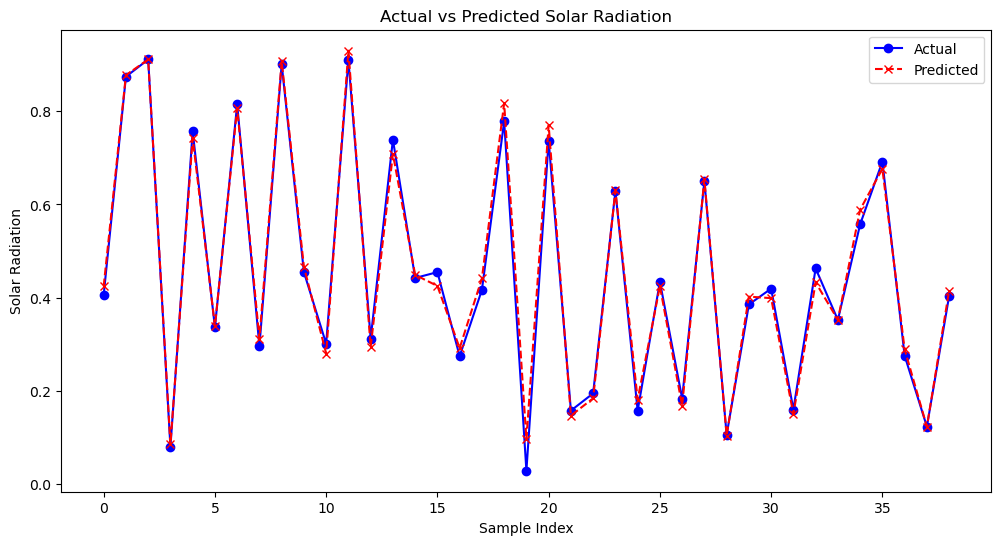

In [8]:
import matplotlib.pyplot as plt

# Plotting Actual vs Predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(y_pred, label='Predicted', color='red', linestyle='--', marker='x')
plt.xlabel('Sample Index')
plt.ylabel('Solar Radiation')
plt.title('Actual vs Predicted Solar Radiation')
plt.legend()
plt.show()

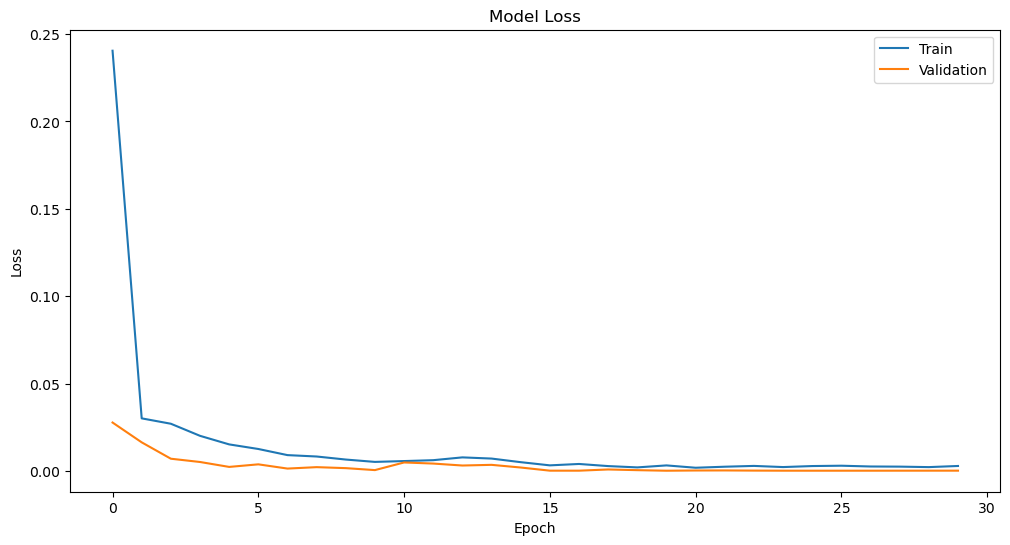

In [9]:
# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

## COMPARISON WITH ADAM OPTIMIZER

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, LayerNormalization, MultiHeadAttention, Dropout, Flatten, Concatenate, Reshape, GlobalAveragePooling1D, Conv1D, MaxPooling1D, SimpleRNN, LSTM
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load your dataset
data = pd.read_csv('./solar_radiation.csv')

# Convert month to numeric values
month_mapping = {month: idx for idx, month in enumerate(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])}
data['month'] = data['month'].map(month_mapping)

# Normalize Features
features = ['H(h)_m', 'H(i_opt)_m', 'H(i)_m', 'Hb(n)_m', 'Kd', 'T2m']
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Define target variable and features
X = data[['H(h)_m', 'H(i_opt)_m', 'H(i)_m', 'Hb(n)_m', 'Kd', 'T2m', 'month']]
y = data['H(h)_m']  # Replace with your actual target column name

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape for CNN, RNN, and LSTM models
X_train_reshaped = X_train.drop(columns='month').values.reshape(X_train.shape[0], X_train.shape[1]-1, 1)
X_test_reshaped = X_test.drop(columns='month').values.reshape(X_test.shape[0], X_test.shape[1]-1, 1)

# Callbacks for early stopping and learning rate reduction
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
]

## CNN MODEL

In [12]:
def build_cnn_model(input_shape):
    model = tf.keras.Sequential([
        Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

cnn_model = build_cnn_model((X_train_reshaped.shape[1], 1))
history_cnn = cnn_model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=callbacks)
y_pred_cnn = cnn_model.predict(X_test_reshaped)

Epoch 1/50


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1239 - val_loss: 0.0642 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0630 - val_loss: 0.0584 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0671 - val_loss: 0.0622 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0641 - val_loss: 0.0542 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0574 - val_loss: 0.0470 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0500 - val_loss: 0.0447 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0504 - val_loss: 0.0427 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0436 - val_loss: 0.0386 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0434 - val_loss: 0.0359 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss:

## RNN MODEL

In [13]:
def build_rnn_model(input_shape):
    model = tf.keras.Sequential([
        SimpleRNN(64, input_shape=input_shape),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

rnn_model = build_rnn_model((X_train_reshaped.shape[1], 1))
history_rnn = rnn_model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=callbacks)
y_pred_rnn = rnn_model.predict(X_test_reshaped)

Epoch 1/50


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1041 - val_loss: 0.0369 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0335 - val_loss: 0.0163 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0159 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0078 - val_loss: 0.0033 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0012 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss:

## LSTM MODEL

In [14]:
def build_lstm_model(input_shape):
    model = tf.keras.Sequential([
        LSTM(64, input_shape=input_shape),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

lstm_model = build_lstm_model((X_train_reshaped.shape[1], 1))
history_lstm = lstm_model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=callbacks)
y_pred_lstm = lstm_model.predict(X_test_reshaped)

Epoch 1/50


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.2337 - val_loss: 0.1769 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1799 - val_loss: 0.1317 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1284 - val_loss: 0.0959 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0907 - val_loss: 0.0677 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0710 - val_loss: 0.0494 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0489 - val_loss: 0.0464 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0459 - val_loss: 0.0497 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0477 - val_loss: 0.0444 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0447 - val_loss: 0.0419 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss:

## PERFORMANCE METRICS

CNN - MAE: 0.009854609176252511, R2: 0.9975810817315212, RMSE: 0.012559728160666932
RNN - MAE: 0.018644611992584364, R2: 0.9907317369601704, RMSE: 0.02458492104912586
LSTM - MAE: 0.1592254043007923, R2: 0.3747098924991473, RMSE: 0.20193445260719875
Transformer - MAE: 0.015880989735032176, R2: 0.9934768620909253, RMSE: 0.020625188322308193


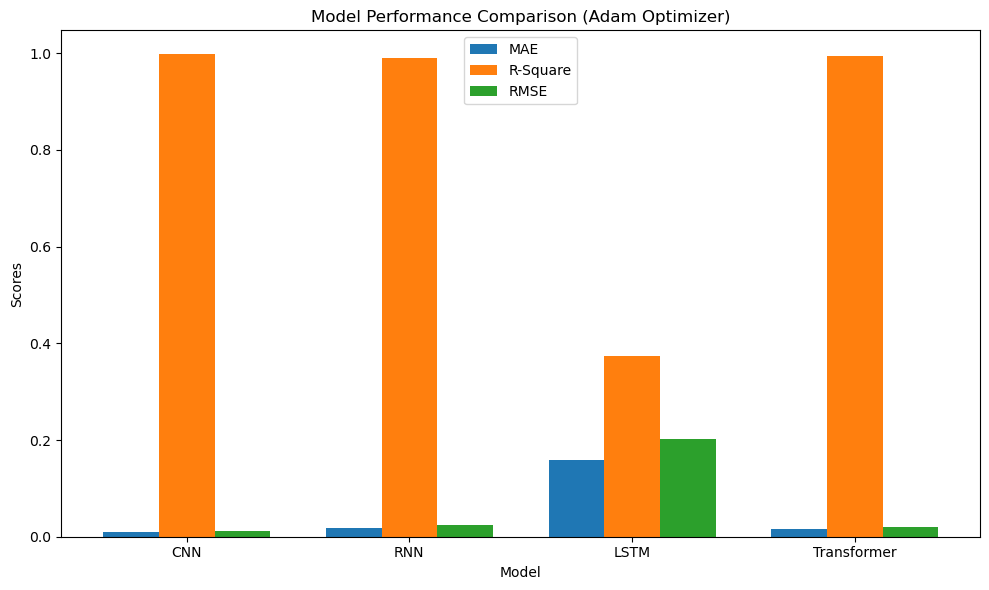

In [15]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Calculate RMSE
    return mae, r2, rmse

# Calculate evaluation metrics for each model
mae_cnn, r2_cnn, rmse_cnn = evaluate_model(y_test, y_pred_cnn)
mae_rnn, r2_rnn, rmse_rnn = evaluate_model(y_test, y_pred_rnn)
mae_lstm, r2_lstm, rmse_lstm = evaluate_model(y_test, y_pred_lstm)
mae_transformer, r2_transformer, rmse_transformer = evaluate_model(y_test, y_pred)

# Print results
print(f"CNN - MAE: {mae_cnn}, R2: {r2_cnn}, RMSE: {rmse_cnn}")
print(f"RNN - MAE: {mae_rnn}, R2: {r2_rnn}, RMSE: {rmse_rnn}")
print(f"LSTM - MAE: {mae_lstm}, R2: {r2_lstm}, RMSE: {rmse_lstm}")
print(f"Transformer - MAE: {mae_transformer}, R2: {r2_transformer}, RMSE: {rmse_transformer}")

# Data for bar graph
models = ['CNN', 'RNN', 'LSTM', 'Transformer']
mae_values = [mae_cnn, mae_rnn, mae_lstm, mae_transformer]
r2_values = [r2_cnn, r2_rnn, r2_lstm, r2_transformer]
rmse_values = [rmse_cnn, rmse_rnn, rmse_lstm, rmse_transformer]

# Plotting the bar chart
x = np.arange(len(models))  # The label locations
width = 0.25  # The width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart for MAE, R2, and RMSE
rects1 = ax.bar(x - width, mae_values, width, label='MAE')
rects2 = ax.bar(x, r2_values, width, label='R-Square')
rects3 = ax.bar(x + width, rmse_values, width, label='RMSE')

# Add some text for labels, title, and custom x-axis tick labels
ax.set_xlabel('Model')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison (Adam Optimizer)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Show the bar chart
plt.tight_layout()
plt.show()


CNN - MAE: 0.009854609176252511, R2: 0.9975810817315212, RMSE: 0.012559728160666932
RNN - MAE: 0.018644611992584364, R2: 0.9907317369601704, RMSE: 0.02458492104912586
LSTM - MAE: 0.1592254043007923, R2: 0.3747098924991473, RMSE: 0.20193445260719875
Transformer - MAE: 0.015880989735032176, R2: 0.9934768620909253, RMSE: 0.020625188322308193


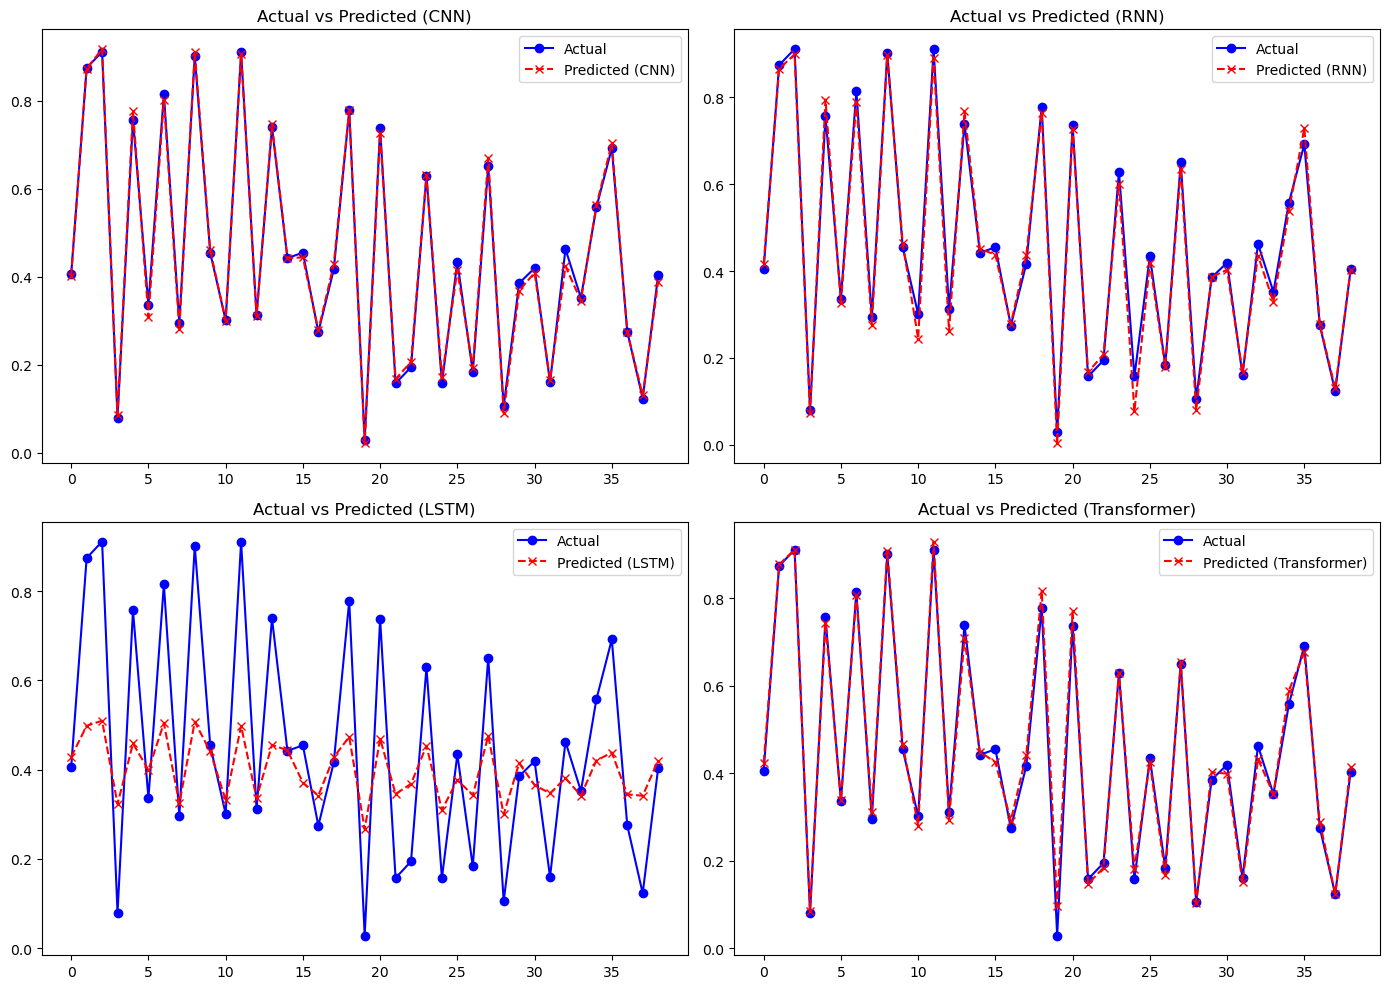

In [16]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Calculate RMSE
    return mae, r2, rmse

# Calculate evaluation metrics for each model
mae_cnn, r2_cnn, rmse_cnn = evaluate_model(y_test, y_pred_cnn)
mae_rnn, r2_rnn, rmse_rnn = evaluate_model(y_test, y_pred_rnn)
mae_lstm, r2_lstm, rmse_lstm = evaluate_model(y_test, y_pred_lstm)
mae_transformer, r2_transformer, rmse_transformer = evaluate_model(y_test, y_pred)

# Print results
print(f"CNN - MAE: {mae_cnn}, R2: {r2_cnn}, RMSE: {rmse_cnn}")
print(f"RNN - MAE: {mae_rnn}, R2: {r2_rnn}, RMSE: {rmse_rnn}")
print(f"LSTM - MAE: {mae_lstm}, R2: {r2_lstm}, RMSE: {rmse_lstm}")
print(f"Transformer - MAE: {mae_transformer}, R2: {r2_transformer}, RMSE: {rmse_transformer}")

# Plotting Actual vs Predicted for all models
plt.figure(figsize=(14, 10))

# CNN Plot
plt.subplot(2, 2, 1)
plt.plot(y_test.values, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(y_pred_cnn, label='Predicted (CNN)', color='red', linestyle='--', marker='x')
plt.title(f'Actual vs Predicted (CNN)')
plt.legend()

# RNN Plot
plt.subplot(2, 2, 2)
plt.plot(y_test.values, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(y_pred_rnn, label='Predicted (RNN)', color='red', linestyle='--', marker='x')
plt.title(f'Actual vs Predicted (RNN)')
plt.legend()

# LSTM Plot
plt.subplot(2, 2, 3)
plt.plot(y_test.values, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(y_pred_lstm, label='Predicted (LSTM)', color='red', linestyle='--', marker='x')
plt.title(f'Actual vs Predicted (LSTM)')
plt.legend()

# Transformer Plot
plt.subplot(2, 2, 4)
plt.plot(y_test.values, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(y_pred, label='Predicted (Transformer)', color='red', linestyle='--', marker='x')
plt.title(f'Actual vs Predicted (Transformer)')
plt.legend()

plt.tight_layout()
plt.show()

## HYBRIDS

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.1473 - val_loss: 0.0718
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0826 - val_loss: 0.0647
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0724 - val_loss: 0.0650
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0627 - val_loss: 0.0584
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0598 - val_loss: 0.0468
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0524 - val_loss: 0.0391
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0508 - val_loss: 0.0339
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0348 - val_loss: 0.0241
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0240 - val_loss: 0.0172
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0224 - val_loss: 0.0111
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0175 - val_loss: 0.0081
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0100 - val_loss: 0.0049
Epoch 13/50


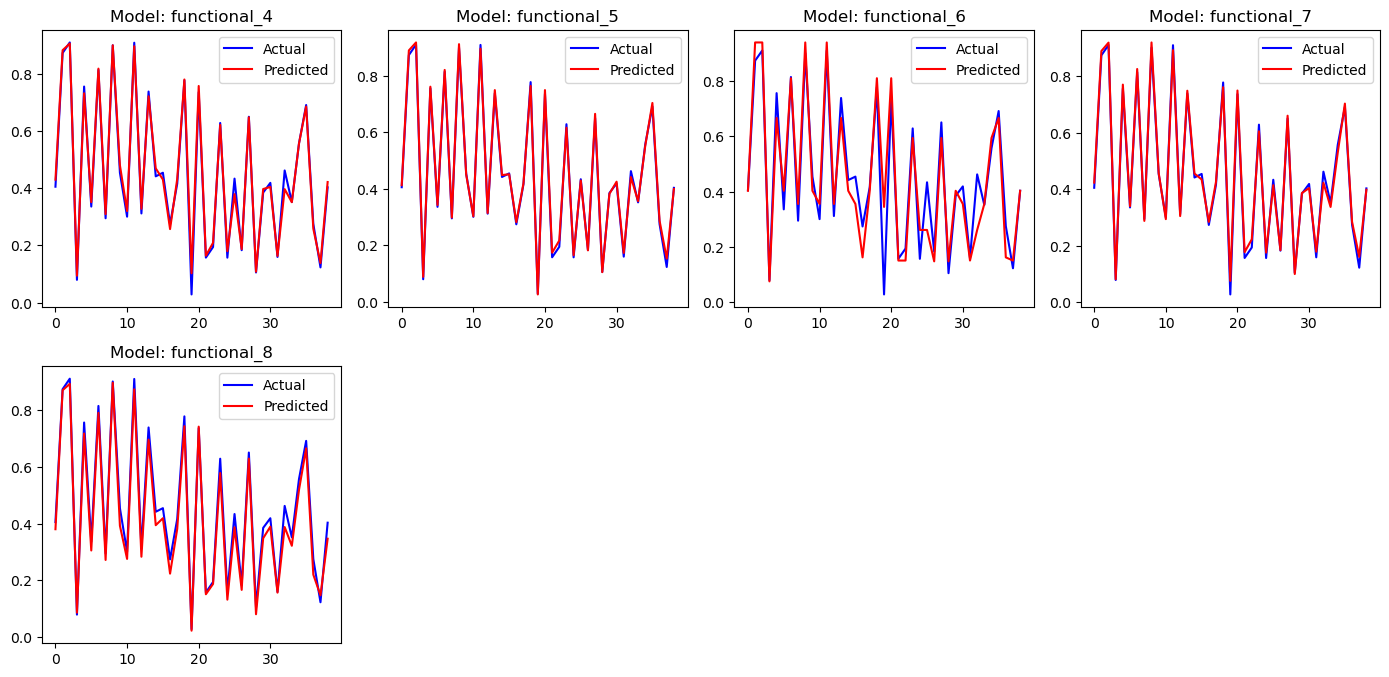

In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Conv1D, MaxPooling1D, Flatten, Embedding, MultiHeadAttention, LayerNormalization, Dropout, Reshape
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Define all hybrid models

def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_out = LSTM(64)(inputs)
    lstm_out = Dense(32, activation='relu')(lstm_out)
    
    transformer_input = Embedding(input_dim=1000, output_dim=32)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = Dropout(0.1)(transformer_out)
    transformer_out = Flatten()(transformer_out)
    transformer_out = Dense(32, activation='relu')(transformer_out)
    
    combined = tf.keras.layers.concatenate([lstm_out, transformer_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model


def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_out = LSTM(64)(inputs)
    lstm_out = Dense(32, activation='relu')(lstm_out)
    
    cnn_out = Conv1D(64, 3, activation='relu')(inputs)
    cnn_out = MaxPooling1D(2)(cnn_out)
    cnn_out = Flatten()(cnn_out)
    cnn_out = Dense(32, activation='relu')(cnn_out)
    
    combined = tf.keras.layers.concatenate([lstm_out, cnn_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model


def build_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    transformer_input = Embedding(input_dim=1000, output_dim=32)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = Dropout(0.1)(transformer_out)
    transformer_out = Flatten()(transformer_out)
    transformer_out = Dense(32, activation='relu')(transformer_out)
    
    transformer_out = Reshape((1, transformer_out.shape[1]))(transformer_out)
    lstm_out = LSTM(64)(transformer_out)
    lstm_out = Dense(32, activation='relu')(lstm_out)
    output = Dense(1)(lstm_out)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model


def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_out = Conv1D(64, 3, activation='relu')(inputs)
    cnn_out = MaxPooling1D(2)(cnn_out)
    cnn_out = Flatten()(cnn_out)
    cnn_out = Dense(32, activation='relu')(cnn_out)
    
    lstm_out = LSTM(64)(inputs)
    lstm_out = Dense(32, activation='relu')(lstm_out)
    
    combined = tf.keras.layers.concatenate([cnn_out, lstm_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model


def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    
    cnn_out = Conv1D(64, 3, activation='relu')(inputs)
    cnn_out = MaxPooling1D(2)(cnn_out)
    cnn_out = Flatten()(cnn_out)
    cnn_out = Dense(32, activation='relu')(cnn_out)
    
    transformer_input = Embedding(input_dim=1000, output_dim=32)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = Dropout(0.1)(transformer_out)
    transformer_out = Flatten()(transformer_out)
    transformer_out = Dense(32, activation='relu')(transformer_out)
    
    combined = tf.keras.layers.concatenate([cnn_out, transformer_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model


# Evaluate Model Performance
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Calculate RMSE
    return mae, r2, rmse

# Prepare your data (X_train, y_train, X_test, y_test should be ready)

# Reshaping the input data to match the expected input shape for LSTM/CNN/Transformer models
X_train_reshaped = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)  # Reshape to (samples, timesteps, features)
X_test_reshaped = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)  # Reshape to (samples, timesteps, features)

models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_transformer_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    # Add other hybrid models here
]

results = {'Model': [], 'RMSE': [], 'MAE': [], 'R-Square': []}

for model in models:
    model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2)
    y_pred = model.predict(X_test_reshaped)
    
    mae, r2, rmse = evaluate_model(y_test, y_pred)
    
    results['Model'].append(model.name)
    results['RMSE'].append(rmse)
    results['MAE'].append(mae)
    results['R-Square'].append(r2)

# Display the results
for i in range(len(results['Model'])):
    print(f"Model: {results['Model'][i]} - MAE: {results['MAE'][i]}, R2: {results['R-Square'][i]}, RMSE: {results['RMSE'][i]}")

# Plotting Actual vs Predicted for all models
plt.figure(figsize=(14, 10)) 
for i, model in enumerate(models):
    y_pred = model.predict(X_test_reshaped)
    plt.subplot(3, 4, i + 1)
    plt.plot(y_test.values, label='Actual', color='blue')
    plt.plot(y_pred, label='Predicted', color='red')
    plt.title(f"Model: {model.name}")
    plt.legend()

plt.tight_layout()
plt.show()


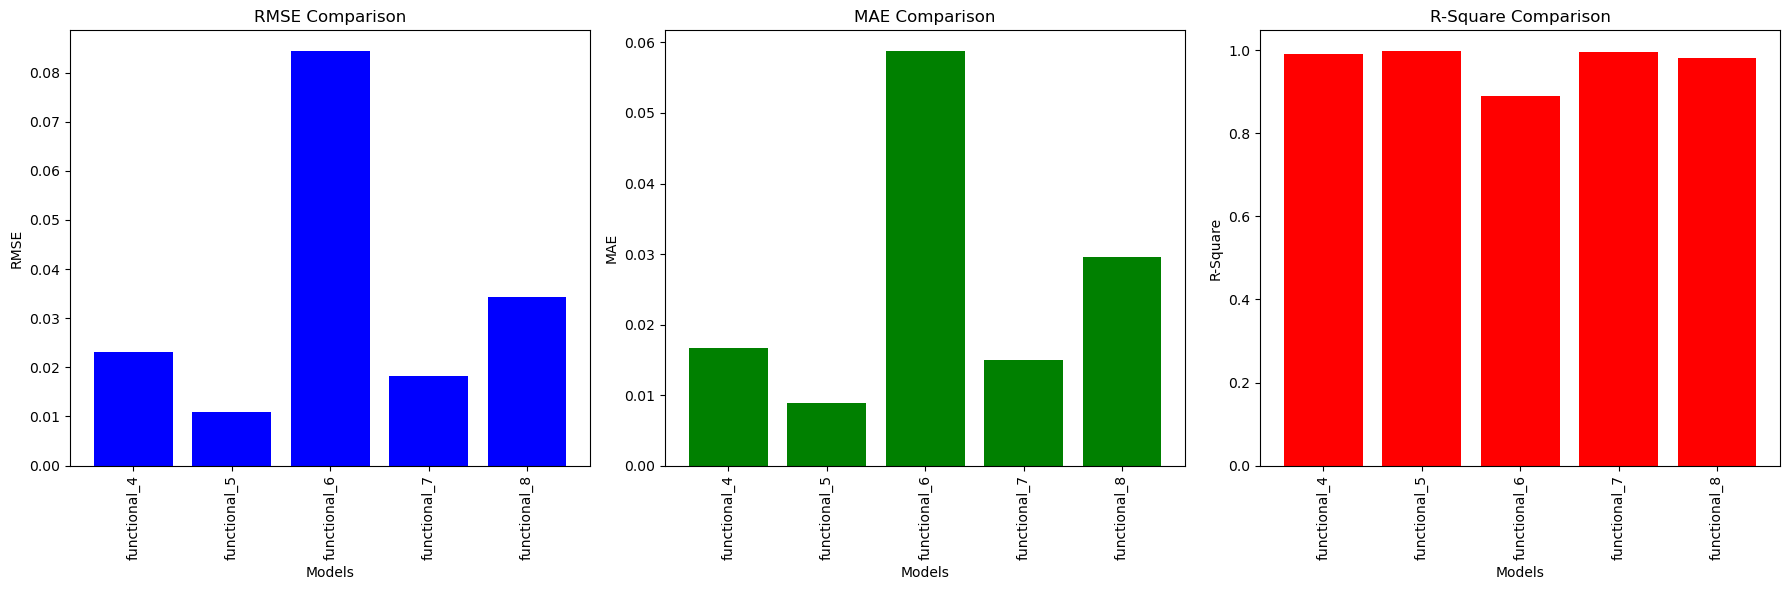

In [18]:
import matplotlib.pyplot as plt

# Assuming 'results' dictionary contains the evaluation metrics for each model:
# results = {'Model': [], 'RMSE': [], 'MAE': [], 'R-Square': []}

# Plotting Bar plots for RMSE, MAE, and R-Square

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# RMSE Plot
axs[0].bar(results['Model'], results['RMSE'], color='blue')
axs[0].set_title('RMSE Comparison')
axs[0].set_xlabel('Models')
axs[0].set_ylabel('RMSE')
axs[0].tick_params(axis='x', rotation=90)  # Rotate model names for better readability

# MAE Plot
axs[1].bar(results['Model'], results['MAE'], color='green')
axs[1].set_title('MAE Comparison')
axs[1].set_xlabel('Models')
axs[1].set_ylabel('MAE')
axs[1].tick_params(axis='x', rotation=90)  # Rotate model names for better readability

# R-Square Plot
axs[2].bar(results['Model'], results['R-Square'], color='red')
axs[2].set_title('R-Square Comparison')
axs[2].set_xlabel('Models')
axs[2].set_ylabel('R-Square')
axs[2].tick_params(axis='x', rotation=90)  # Rotate model names for better readability

# Adjust the layout and show the plots
plt.tight_layout()
plt.show()


Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.4363e-04 - val_loss: 3.3844e-04
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2195e-04 - val_loss: 3.8528e-04
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.6105e-04 - val_loss: 5.1684e-04
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.2215e-04 - val_loss: 3.9769e-04
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.7171e-04 - val_loss: 4.0668e-04
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.7336e-04 - val_loss: 3.4824e-04
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.3035e-04 - val_loss: 4.8523e-04
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.2618e-04 - val_loss: 4.3104e-04
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.7784e-04 - val_loss: 3.0843e-04
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.6712e-04 - val_loss: 3.6265e-04
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.7917e-04 - val_loss: 3.6147e-04
Epoch 1

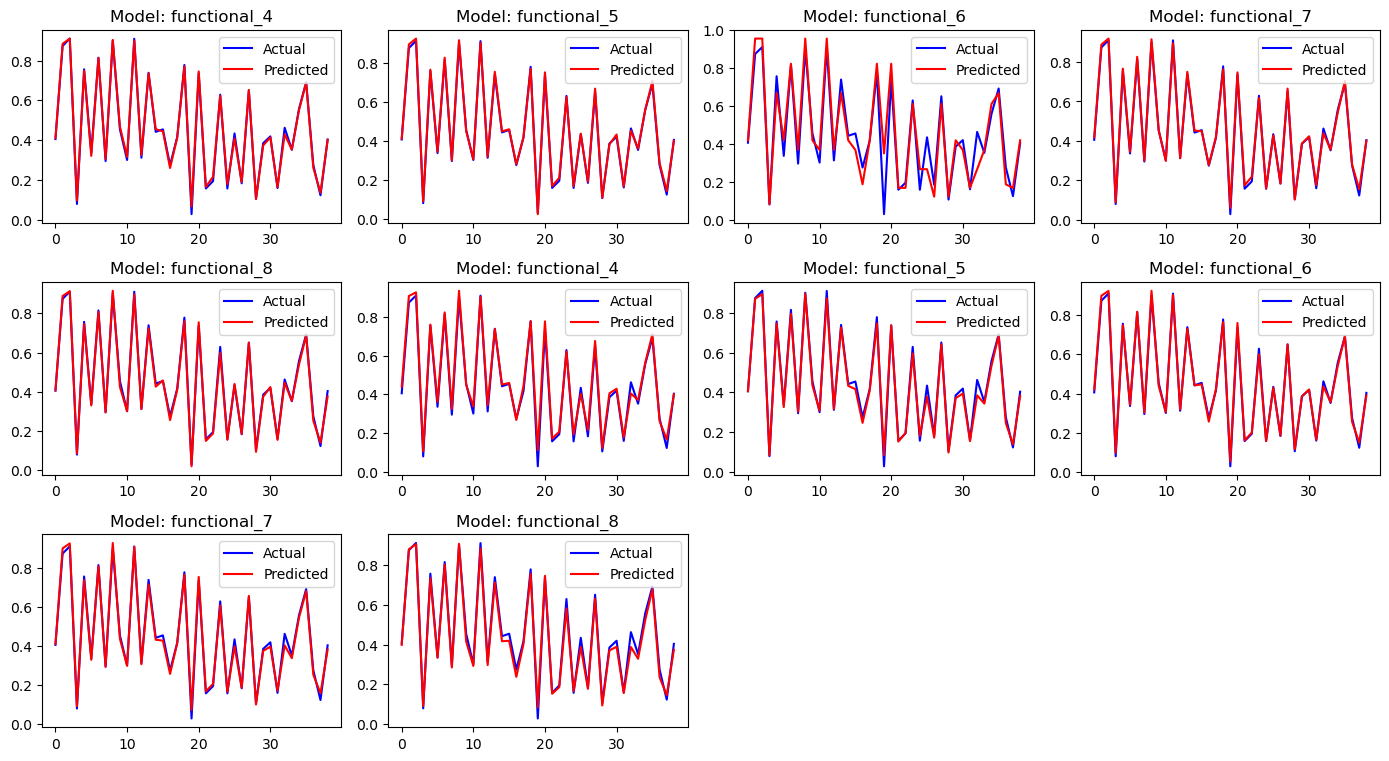

In [19]:
# Define the missing hybrid models

def build_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    
    transformer_input = Embedding(input_dim=1000, output_dim=32)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = Dropout(0.1)(transformer_out)
    transformer_out = Flatten()(transformer_out)
    transformer_out = Dense(32, activation='relu')(transformer_out)
    
    cnn_out = Conv1D(64, 3, activation='relu')(inputs)
    cnn_out = MaxPooling1D(2)(cnn_out)
    cnn_out = Flatten()(cnn_out)
    cnn_out = Dense(32, activation='relu')(cnn_out)
    
    combined = tf.keras.layers.concatenate([transformer_out, cnn_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    
    cnn_out = Conv1D(64, 3, activation='relu')(inputs)
    cnn_out = MaxPooling1D(2)(cnn_out)
    cnn_out = Flatten()(cnn_out)
    cnn_out = Dense(32, activation='relu')(cnn_out)
    
    lstm_out = LSTM(64)(inputs)
    lstm_out = Dense(32, activation='relu')(lstm_out)
    
    transformer_input = Embedding(input_dim=1000, output_dim=32)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = Dropout(0.1)(transformer_out)
    transformer_out = Flatten()(transformer_out)
    transformer_out = Dense(32, activation='relu')(transformer_out)
    
    combined = tf.keras.layers.concatenate([cnn_out, lstm_out, transformer_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def build_lstm_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    
    lstm_out = LSTM(64)(inputs)
    lstm_out = Dense(32, activation='relu')(lstm_out)
    
    cnn_out = Conv1D(64, 3, activation='relu')(inputs)
    cnn_out = MaxPooling1D(2)(cnn_out)
    cnn_out = Flatten()(cnn_out)
    cnn_out = Dense(32, activation='relu')(cnn_out)
    
    transformer_input = Embedding(input_dim=1000, output_dim=32)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = Dropout(0.1)(transformer_out)
    transformer_out = Flatten()(transformer_out)
    transformer_out = Dense(32, activation='relu')(transformer_out)
    
    combined = tf.keras.layers.concatenate([lstm_out, cnn_out, transformer_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def build_cnn_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    
    cnn_out = Conv1D(64, 3, activation='relu')(inputs)
    cnn_out = MaxPooling1D(2)(cnn_out)
    cnn_out = Flatten()(cnn_out)
    cnn_out = Dense(32, activation='relu')(cnn_out)
    
    transformer_input = Embedding(input_dim=1000, output_dim=32)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = Dropout(0.1)(transformer_out)
    transformer_out = Flatten()(transformer_out)
    transformer_out = Dense(32, activation='relu')(transformer_out)
    
    lstm_out = LSTM(64)(inputs)
    lstm_out = Dense(32, activation='relu')(lstm_out)
    
    combined = tf.keras.layers.concatenate([cnn_out, transformer_out, lstm_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def build_lstm_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    
    lstm_out = LSTM(64)(inputs)
    lstm_out = Dense(32, activation='relu')(lstm_out)
    
    transformer_input = Embedding(input_dim=1000, output_dim=32)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = Dropout(0.1)(transformer_out)
    transformer_out = Flatten()(transformer_out)
    transformer_out = Dense(32, activation='relu')(transformer_out)
    
    cnn_out = Conv1D(64, 3, activation='relu')(inputs)
    cnn_out = MaxPooling1D(2)(cnn_out)
    cnn_out = Flatten()(cnn_out)
    cnn_out = Dense(32, activation='relu')(cnn_out)
    
    combined = tf.keras.layers.concatenate([lstm_out, transformer_out, cnn_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Add models to the list
models.extend([
    build_transformer_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer_lstm((X_train_reshaped.shape[1], 1)),
    build_lstm_transformer_cnn((X_train_reshaped.shape[1], 1)),
])

# Evaluate all models
for model in models:
    model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2)
    y_pred = model.predict(X_test_reshaped)
    mae, r2, rmse = evaluate_model(y_test, y_pred)
    results['Model'].append(model.name)
    results['RMSE'].append(rmse)
    results['MAE'].append(mae)
    results['R-Square'].append(r2)

# Final comparison table
import pandas as pd

results_df = pd.DataFrame(results)
results_df.sort_values(by='RMSE', inplace=True)
print("Model Performance Comparison:")
print(results_df)

# Final Plot
plt.figure(figsize=(14, 10))
for i, model in enumerate(models):
    y_pred = model.predict(X_test_reshaped)
    plt.subplot(4, 4, i + 1)
    plt.plot(y_test.values, label='Actual', color='blue')
    plt.plot(y_pred, label='Predicted', color='red')
    plt.title(f"Model: {results['Model'][i]}")
    plt.legend()

plt.tight_layout()
plt.show()

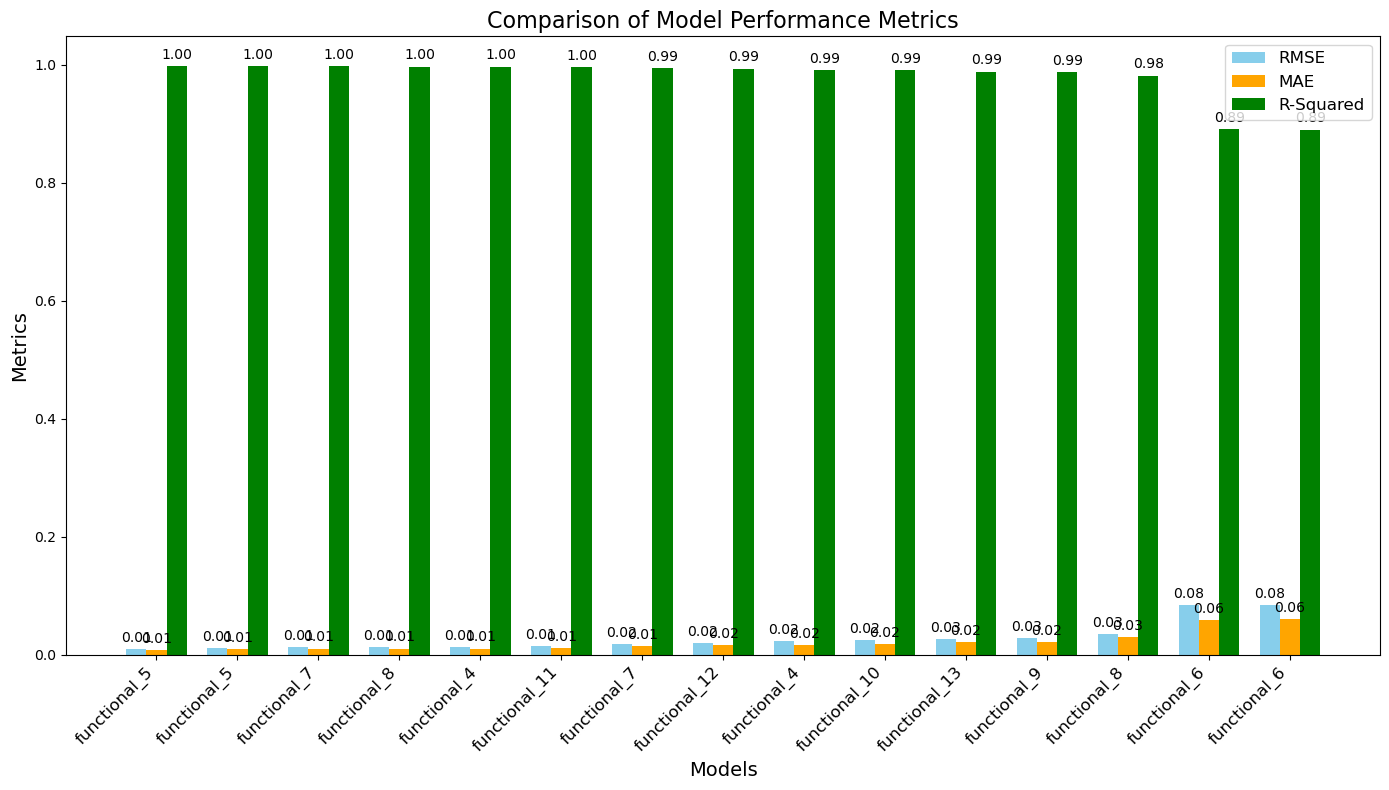

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure `results_df` contains your performance metrics as a pandas DataFrame
# with columns: 'Model', 'RMSE', 'MAE', 'R-Square'

# Set positions for bars
x = np.arange(len(results_df['Model']))  # the label locations
width = 0.25  # the width of the bars

# Create the bar plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot RMSE
bars_rmse = ax.bar(x - width, results_df['RMSE'], width, label='RMSE', color='skyblue')

# Plot MAE
bars_mae = ax.bar(x, results_df['MAE'], width, label='MAE', color='orange')

# Plot R-Squared (scaled for better visualization)
bars_r2 = ax.bar(x + width, results_df['R-Square'], width, label='R-Squared', color='green')

# Add text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Models', fontsize=14)
ax.set_ylabel('Metrics', fontsize=14)
ax.set_title('Comparison of Model Performance Metrics', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=12)
ax.legend(fontsize=12)

# Annotate bar values
def annotate_bars(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

annotate_bars(bars_rmse)
annotate_bars(bars_mae)
annotate_bars(bars_r2)

# Adjust layout
fig.tight_layout()

# Show the plot
plt.show()

In [21]:
# Define models with corresponding names
model_names = [
    'LSTM-Transformer',
    'LSTM-CNN',
    'Transformer-LSTM',
    'CNN-LSTM',
    'CNN-Transformer',
    'Transformer-CNN',
    'CNN-LSTM-Transformer',
    'LSTM-CNN-Transformer',
    'CNN-Transformer-LSTM',
    'LSTM-Transformer-CNN',
    'Transformer-CNN-LSTM',
    'Transformer-LSTM-CNN'
]

# Collect results into a DataFrame with explicit model names
results = {'Model': [], 'RMSE': [], 'MAE': [], 'R-Square': []}

for name, model in zip(model_names, models):
    print(f"Training and evaluating model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)

    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results['Model'].append(name)
    results['RMSE'].append(rmse)
    results['MAE'].append(mae)
    results['R-Square'].append(r2)

# Convert results to a DataFrame
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

Training and evaluating model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training and evaluating model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating model: Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating model: Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating model: LSTM-CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training and evaluating model: CNN-Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating model: LSTM-Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.008840  0.998093  0.011151
1              LSTM-CNN  0.006489  0.998799 

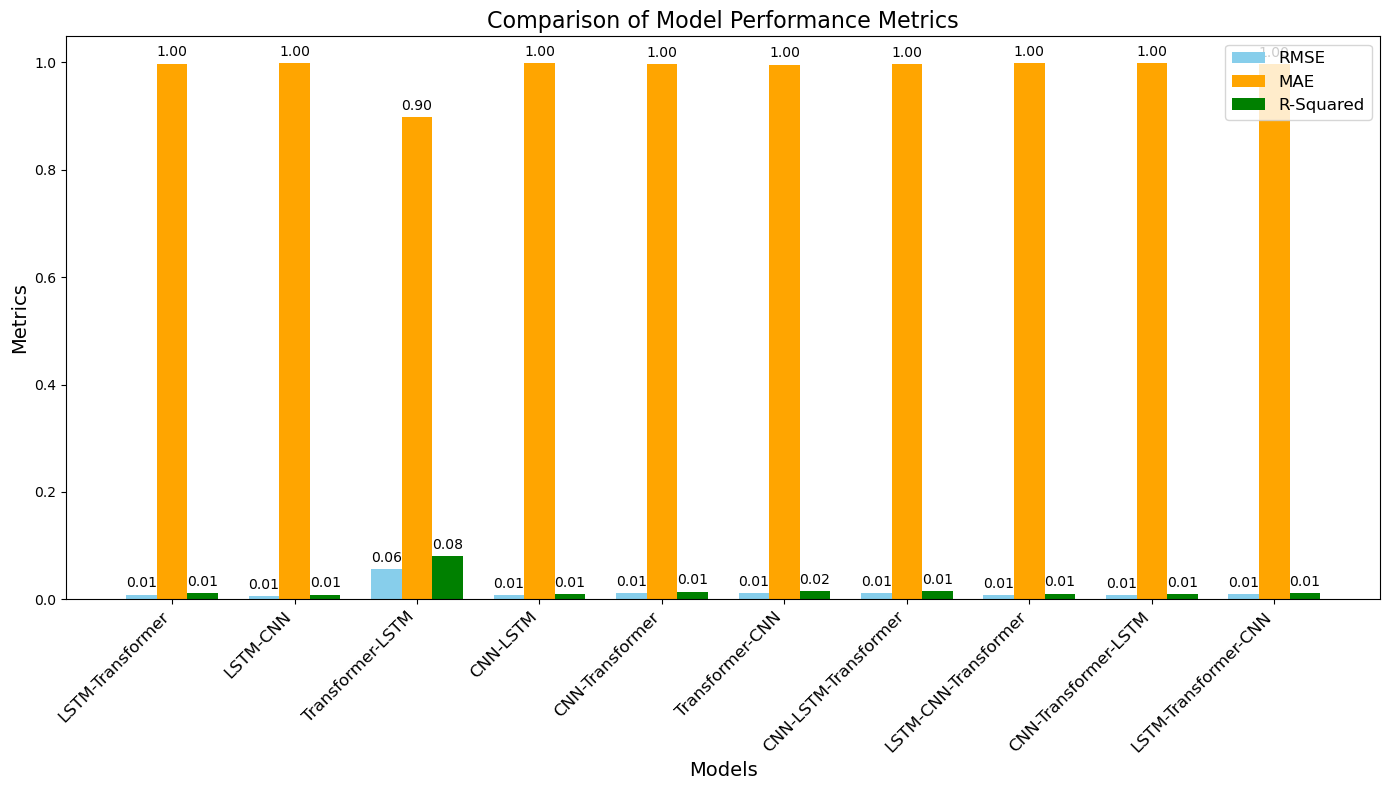

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Set positions for bars
x = np.arange(len(results_df['Model']))  # the label locations
width = 0.25  # the width of the bars

# Create the bar plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot RMSE
bars_rmse = ax.bar(x - width, results_df['RMSE'], width, label='RMSE', color='skyblue')

# Plot MAE
bars_mae = ax.bar(x, results_df['MAE'], width, label='MAE', color='orange')

# Plot R-Squared (scaled for better visualization)
bars_r2 = ax.bar(x + width, results_df['R-Square'], width, label='R-Squared', color='green')

# Add text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Models', fontsize=14)
ax.set_ylabel('Metrics', fontsize=14)
ax.set_title('Comparison of Model Performance Metrics', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=12)
ax.legend(fontsize=12)

# Annotate bar values
def annotate_bars(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

annotate_bars(bars_rmse)
annotate_bars(bars_mae)
annotate_bars(bars_r2)

# Adjust layout
fig.tight_layout()

# Show the plot
plt.show()

## COMPARISON 2( WITH ADAM OPTIMIZER)

Training and evaluating model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Training and evaluating model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Training and evaluating model: Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Training and evaluating model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Training and evaluating model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Training and evaluating model: Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Training and evaluating model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Training and evaluating model: LSTM-CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Training and evaluating model: CNN-Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Training and evaluating model: LSTM-Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.208769  0.166475  0.331670
1              LSTM-CNN  0.157763 

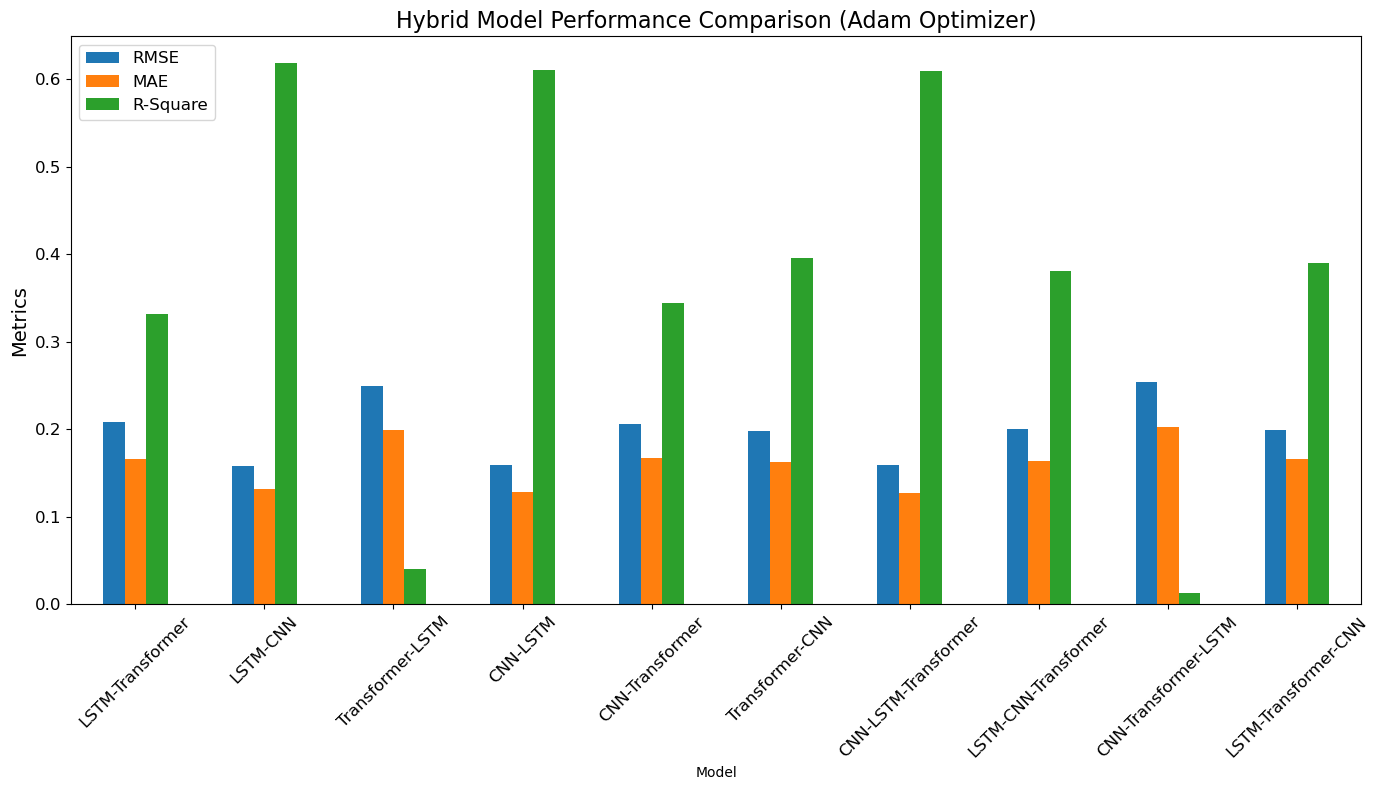

In [23]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Conv1D, Flatten, Reshape, Dropout, LayerNormalization, MultiHeadAttention
)
from tensorflow.keras.optimizers import Adam

# Define hybrid models
def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    transformer_output = Reshape((transformer_output.shape[1], 1))(transformer_output)
    lstm_output = LSTM(64)(transformer_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(transformer_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    transformer_output = Reshape((transformer_output.shape[1], 1))(transformer_output)
    lstm_output = LSTM(64)(transformer_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(transformer_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

# Dataset preparation
# Assuming data is preprocessed into X_train_reshaped, y_train, X_test_reshaped, y_test

# Define models and their names
models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_transformer_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_transformer_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer_lstm((X_train_reshaped.shape[1], 1)),
    build_lstm_transformer_cnn((X_train_reshaped.shape[1], 1)),
]

model_names = [
    "LSTM-Transformer",
    "LSTM-CNN",
    "Transformer-LSTM",
    "CNN-LSTM",
    "CNN-Transformer",
    "Transformer-CNN",
    "CNN-LSTM-Transformer",
    "LSTM-CNN-Transformer",
    "CNN-Transformer-LSTM",
    "LSTM-Transformer-CNN",
]

# Evaluate models
results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

for name, model in zip(model_names, models):
    print(f"Training and evaluating model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results["Model"].append(name)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    results["R-Square"].append(r2)

# Plotting results
results_df = pd.DataFrame(results)
print(results_df)

# Bar plot for comparison
results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Hybrid Model Performance Comparison (Adam Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

In [25]:
import numpy as np
import pandas as pd
import time
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Conv1D, Flatten, MultiHeadAttention
)

# Function to build models
def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

# Define models
models = ["LSTM-TF", "LSTM-CNN", "CNN-LSTM", "CNN-TF", "CNN-LSTM-TF"]

# Placeholder for computation times
results = []

for model_name in models:
    print(f"Training {model_name} with Adam")
    model = build_lstm_cnn((X_train_reshaped.shape[1], 1))
    start_time = time.time()
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, verbose=0)
    end_time = time.time()
    
    results.append([model_name, "Adam", end_time - start_time])

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Optimizer", "Computation Time (s)"])
print(results_df)

# Save results to CSV
results_df.to_csv("computation_times_adam.csv", index=False)


Training LSTM-TF with Adam
Training LSTM-CNN with Adam
Training CNN-LSTM with Adam
Training CNN-TF with Adam
Training CNN-LSTM-TF with Adam
         Model Optimizer  Computation Time (s)
0      LSTM-TF      Adam              1.160594
1     LSTM-CNN      Adam              0.638814
2     CNN-LSTM      Adam              0.641297
3       CNN-TF      Adam              0.635299
4  CNN-LSTM-TF      Adam              0.638663


# NADAM AS AN OPTIMIZER

/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training and evaluating model: LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Training and evaluating model: CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Training and evaluating model: RNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Training and evaluating model: Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
         Model      RMSE       MAE  R-Square
0         LSTM  0.117147  0.095480  0.789564
1          CNN  0.240404  0.191534  0.113777
2          RNN  0.032973  0.029008  0.983328
3  Transformer  0.185975  0.166425  0.469642


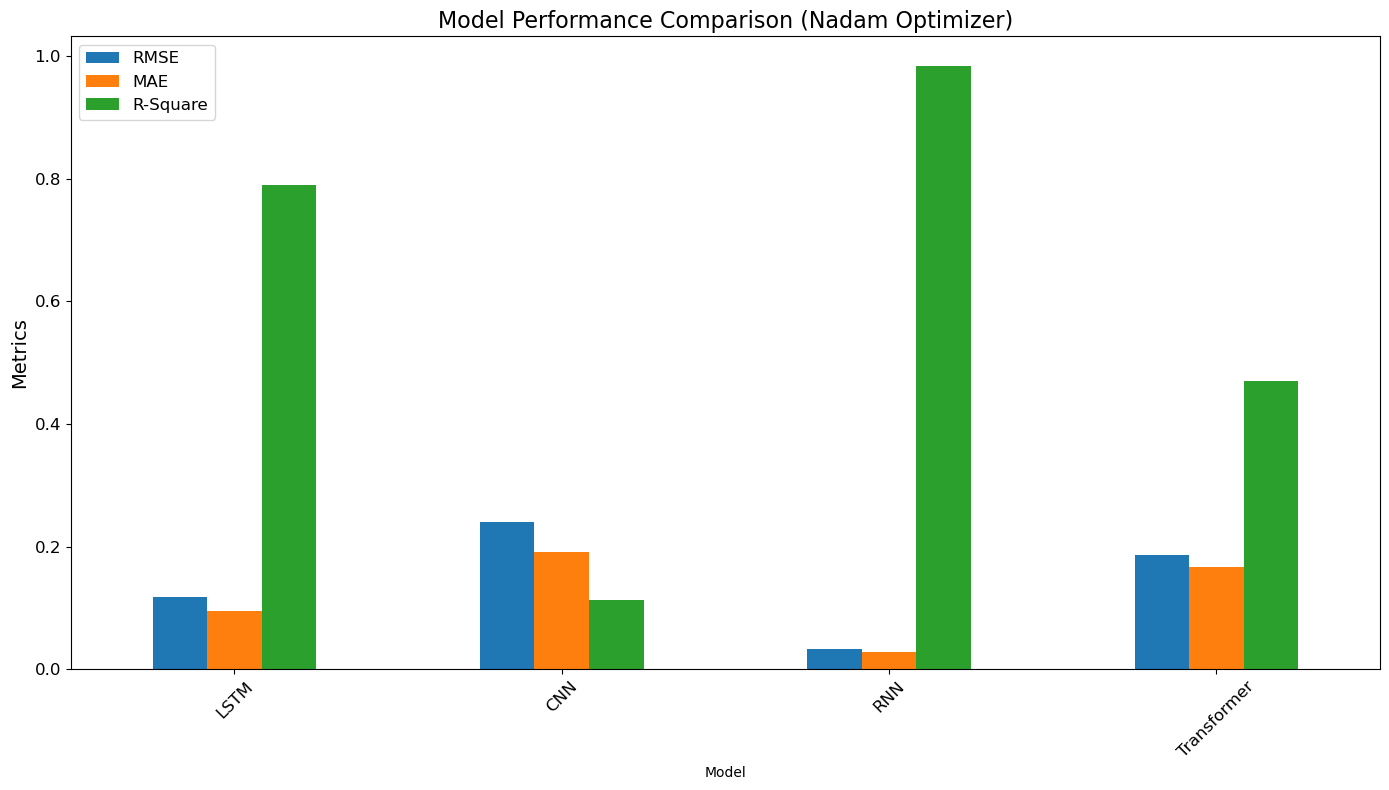

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten, Input, MultiHeadAttention, Reshape
from tensorflow.keras.optimizers import Nadam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define individual models using Nadam optimizer
def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn(input_shape):
    model = Sequential()
    model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(Flatten())
    model.add(Dense(1))
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_rnn(input_shape):
    model = Sequential()
    model.add(SimpleRNN(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

# Dataset preparation
# Assuming data is preprocessed into X_train_reshaped, y_train, X_test_reshaped, y_test

models = [
    build_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn((X_train_reshaped.shape[1], 1)),
    build_rnn((X_train_reshaped.shape[1], 1)),
    build_transformer((X_train_reshaped.shape[1], 1)),
]

model_names = [
    "LSTM",
    "CNN",
    "RNN",
    "Transformer",
]

# Evaluate models
results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

for name, model in zip(model_names, models):
    print(f"Training and evaluating model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results["Model"].append(name)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    results["R-Square"].append(r2)

# Plotting results
results_df = pd.DataFrame(results)
print(results_df)

# Bar plot for comparison
results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Model Performance Comparison (Nadam Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

Training and evaluating model: LSTM with Nadam
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Training and evaluating model: CNN with Nadam
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Training and evaluating model: RNN with Nadam
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Training and evaluating model: Transformer with Nadam
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
         Model      RMSE       MAE  R-Square  Computation Time (s)
0         LSTM  0.163840  0.130735  0.588375              1.171271
1          CNN  0.209384  0.162620  0.327727              0.467427
2          RNN  0.030769  0.024159  0.985483              0.658772
3  Transformer  0.207786  0.175079  0.337947              0.789221


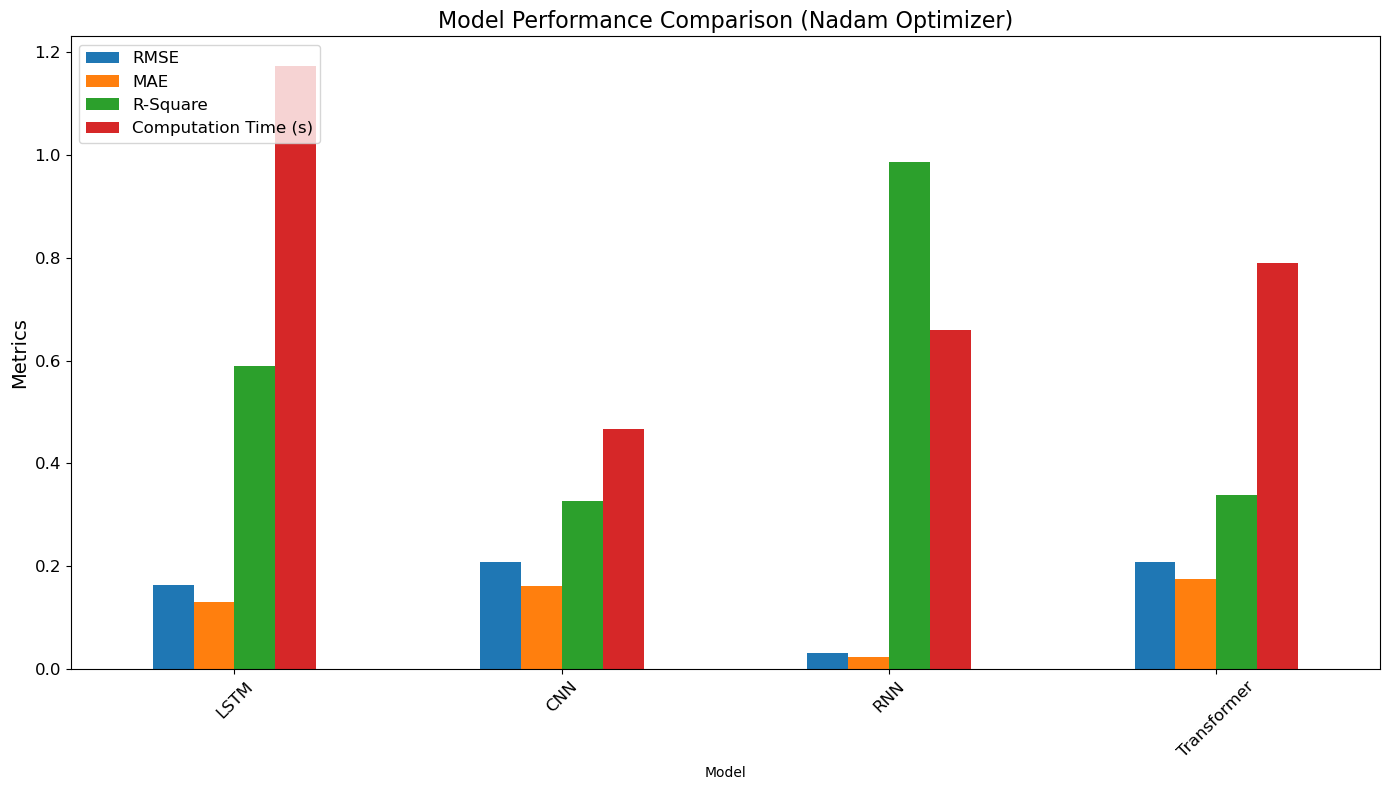

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten, Input, MultiHeadAttention, Reshape, SimpleRNN
from tensorflow.keras.optimizers import Nadam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Function to build LSTM model
def build_lstm(input_shape, optimizer):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=False),
        Dense(1)
    ])
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
    return model

# Function to build CNN model
def build_cnn(input_shape, optimizer):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(32, kernel_size=3, activation='relu'),
        Flatten(),
        Dense(1)
    ])
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
    return model

# Function to build RNN model
def build_rnn(input_shape, optimizer):
    model = Sequential([
        Input(shape=input_shape),
        SimpleRNN(64, return_sequences=False),
        Dense(1)
    ])
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
    return model

# Function to build Transformer model
def build_transformer(input_shape, optimizer):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
    return model

# Dataset preparation
# Assuming data is preprocessed into X_train_reshaped, y_train, X_test_reshaped, y_test

models = {
    "LSTM": build_lstm((X_train_reshaped.shape[1], 1), Nadam()),
    "CNN": build_cnn((X_train_reshaped.shape[1], 1), Nadam()),
    "RNN": build_rnn((X_train_reshaped.shape[1], 1), Nadam()),
    "Transformer": build_transformer((X_train_reshaped.shape[1], 1), Nadam()),
}

# Performance metrics storage
results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": [], "Computation Time (s)": []}

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Training and Evaluation
for name, model in models.items():
    print(f"Training and evaluating model: {name} with Nadam")
    
    start_time = time.time()
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    end_time = time.time()

    y_pred = model.predict(X_test_reshaped).squeeze()
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    
    results["Model"].append(name)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    results["R-Square"].append(r2)
    results["Computation Time (s)"].append(end_time - start_time)

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

# Bar plot for comparison
results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Model Performance Comparison (Nadam Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()


# HYBRID WITH NADAM

Training and evaluating hybrid model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Training and evaluating hybrid model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Training and evaluating hybrid model: Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Training and evaluating hybrid model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Training and evaluating hybrid model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Training and evaluating hybrid model: Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step
Training and evaluating hybrid model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Training and evaluating hybrid model: LSTM-CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.153577  0.135036  0.638331
1              LSTM-CNN  0.168854  0.142603  0.562796
2      Transformer-LSTM  0.234418  0.187460  0.157360
3              CNN-LSTM  0.140642  0.113014  0.69

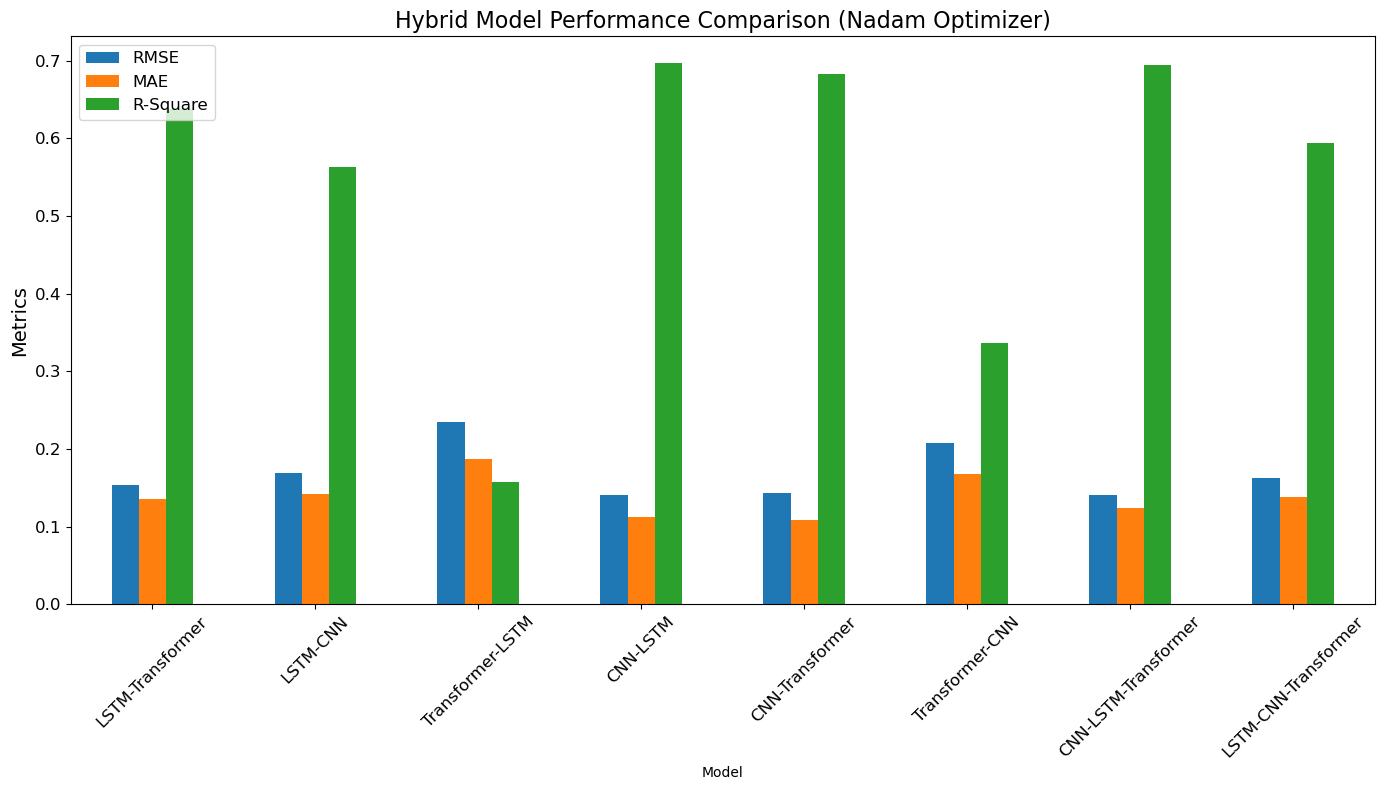

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, Flatten, Reshape, MultiHeadAttention
from tensorflow.keras.optimizers import Nadam

# Define hybrid models with Nadam optimizer

def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    transformer_output = Reshape((transformer_output.shape[1], 1))(transformer_output)
    lstm_output = LSTM(64)(transformer_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(transformer_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

# Define all hybrid models in a list
hybrid_models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_transformer_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_transformer_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn_transformer((X_train_reshaped.shape[1], 1)),
]

hybrid_model_names = [
    "LSTM-Transformer",
    "LSTM-CNN",
    "Transformer-LSTM",
    "CNN-LSTM",
    "CNN-Transformer",
    "Transformer-CNN",
    "CNN-LSTM-Transformer",
    "LSTM-CNN-Transformer",
]

# Evaluate hybrid models
hybrid_results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

for name, model in zip(hybrid_model_names, hybrid_models):
    print(f"Training and evaluating hybrid model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    hybrid_results["Model"].append(name)
    hybrid_results["RMSE"].append(rmse)
    hybrid_results["MAE"].append(mae)
    hybrid_results["R-Square"].append(r2)

# Plotting hybrid model results
hybrid_results_df = pd.DataFrame(hybrid_results)
print(hybrid_results_df)

# Bar plot for comparison
hybrid_results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Hybrid Model Performance Comparison (Nadam Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()


Training and evaluating hybrid model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Training and evaluating hybrid model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Training and evaluating hybrid model: Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Training and evaluating hybrid model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Training and evaluating hybrid model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Training and evaluating hybrid model: Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step
Training and evaluating hybrid model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Training and evaluating hybrid model: LSTM-CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.153577  0.135036  0.638331
1              LSTM-CNN  0.168854  0.142603  0.562796
2      Transformer-LSTM  0.234418  0.187460  0.157360
3              CNN-LSTM  0.140642  0.113014  0.69

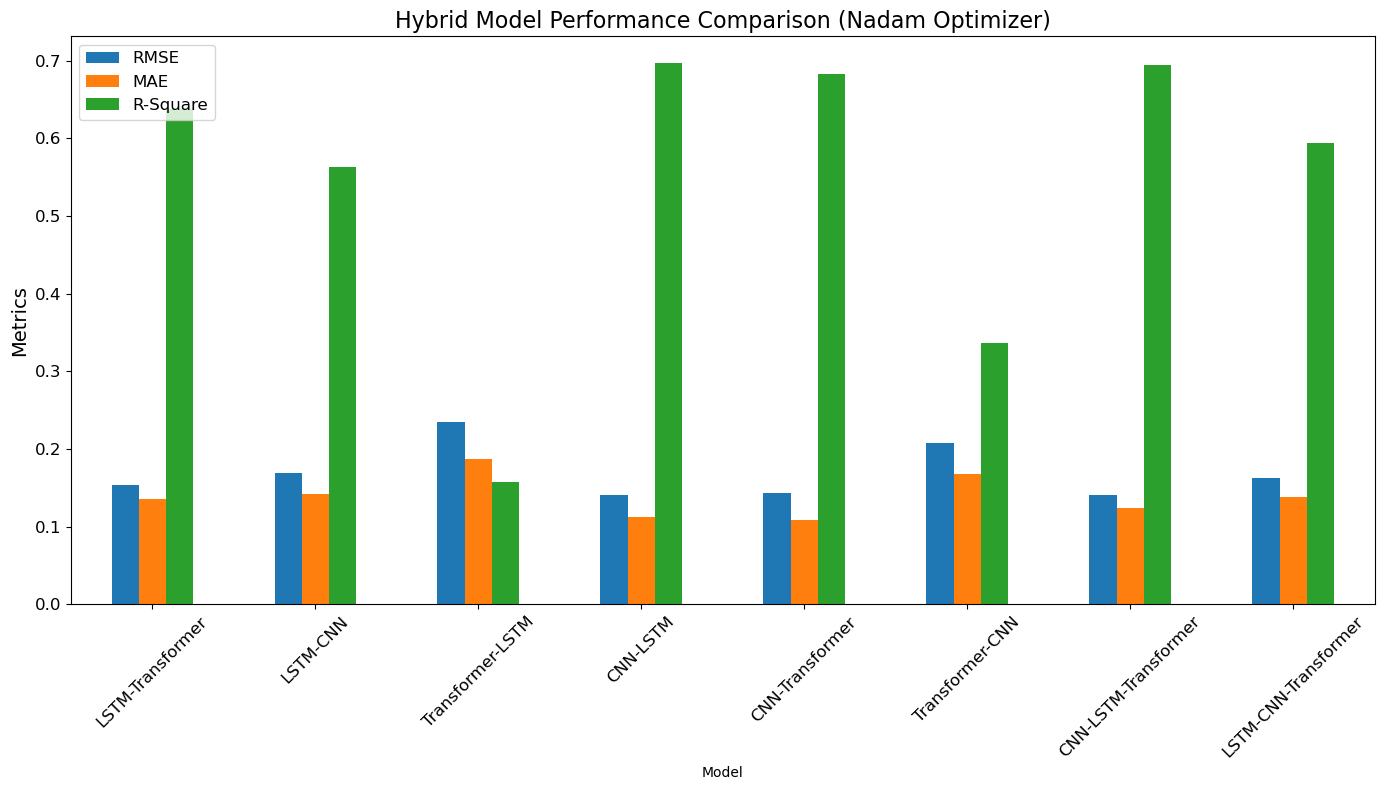

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, Flatten, Reshape, MultiHeadAttention
from tensorflow.keras.optimizers import Nadam

# Define hybrid models with Nadam optimizer

def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    transformer_output = Reshape((transformer_output.shape[1], 1))(transformer_output)
    lstm_output = LSTM(64)(transformer_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(transformer_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

# Define all hybrid models in a list
hybrid_models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_transformer_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_transformer_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn_transformer((X_train_reshaped.shape[1], 1)),
]

hybrid_model_names = [
    "LSTM-Transformer",
    "LSTM-CNN",
    "Transformer-LSTM",
    "CNN-LSTM",
    "CNN-Transformer",
    "Transformer-CNN",
    "CNN-LSTM-Transformer",
    "LSTM-CNN-Transformer",
]

# Evaluate hybrid models
hybrid_results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

for name, model in zip(hybrid_model_names, hybrid_models):
    print(f"Training and evaluating hybrid model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    hybrid_results["Model"].append(name)
    hybrid_results["RMSE"].append(rmse)
    hybrid_results["MAE"].append(mae)
    hybrid_results["R-Square"].append(r2)

# Plotting hybrid model results
hybrid_results_df = pd.DataFrame(hybrid_results)
print(hybrid_results_df)

# Bar plot for comparison
hybrid_results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Hybrid Model Performance Comparison (Nadam Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()


Training and evaluating model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Training and evaluating model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Training and evaluating model: Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Training and evaluating model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Training and evaluating model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
                  Model      RMSE       MAE  R-Square  Computation Time (s)
0      LSTM-Transformer  0.149888  0.133005  0.655494              1.301922
1              LSTM-CNN  0.175901  0.147080  0.525544              0.888152
2      Transformer-LSTM  0.174366  0.146203  0.533789              1.242011
3              CNN-LSTM  0.123709  0.096835  0.765326              0.952427
4  CNN-LSTM-Transformer  0.150964  0.127372  0.650534              1.356365


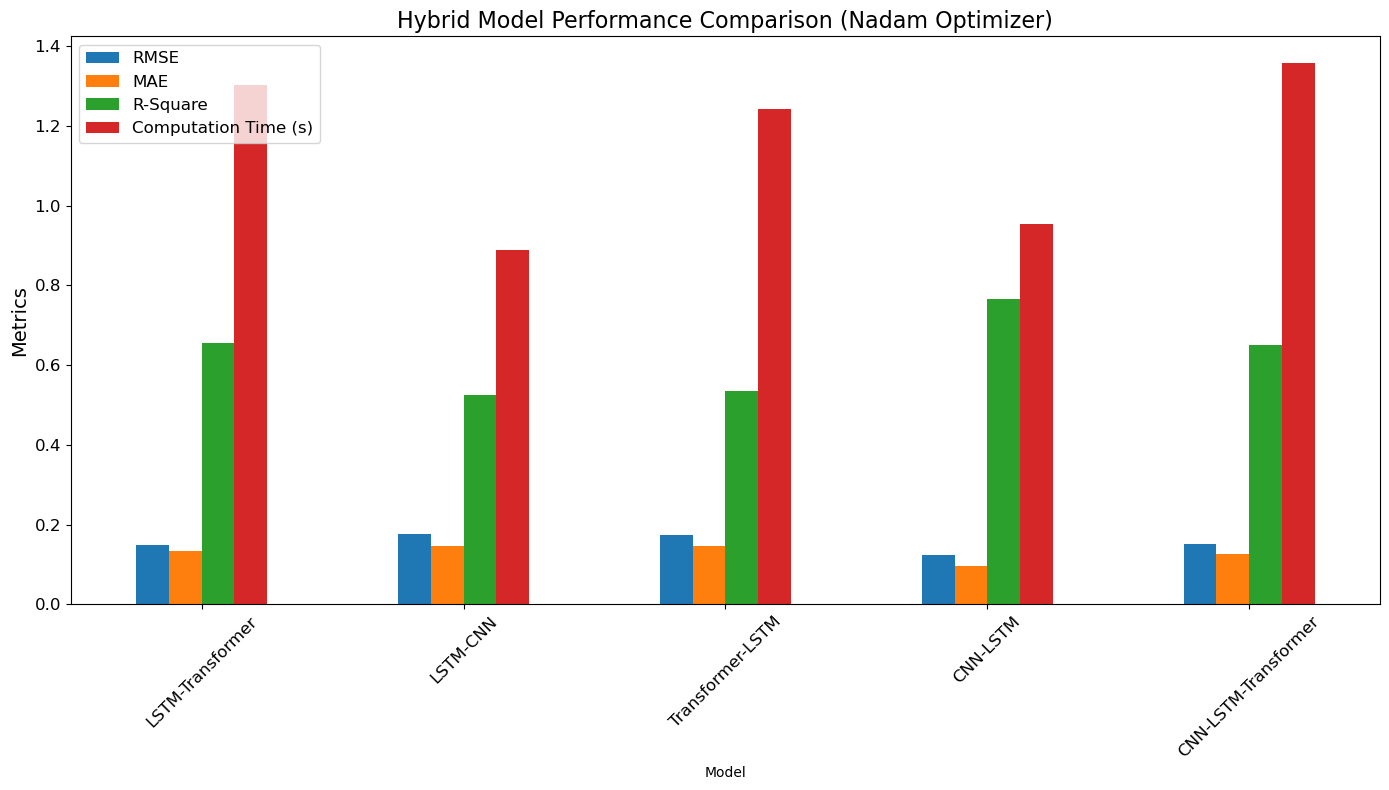

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, Flatten, Reshape, MultiHeadAttention
from tensorflow.keras.optimizers import Nadam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define evaluation function
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Define hybrid models with fresh optimizer instances
def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    transformer_output = Reshape((transformer_output.shape[1], 1))(transformer_output)
    lstm_output = LSTM(64)(transformer_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

# Define models
target_shape = (X_train_reshaped.shape[1], 1)
models = {
    "LSTM-Transformer": build_lstm_transformer(target_shape),
    "LSTM-CNN": build_lstm_cnn(target_shape),
    "Transformer-LSTM": build_transformer_lstm(target_shape),
    "CNN-LSTM": build_cnn_lstm(target_shape),
    "CNN-LSTM-Transformer": build_cnn_lstm_transformer(target_shape),
}

# Store results
results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": [], "Computation Time (s)": []}

# Training and evaluation
for name, model in models.items():
    print(f"Training and evaluating model: {name}")
    start_time = time.time()
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    end_time = time.time()
    
    y_pred = model.predict(X_test_reshaped).squeeze()
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    
    results["Model"].append(name)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    results["R-Square"].append(r2)
    results["Computation Time (s)"].append(end_time - start_time)

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

# Plot results
results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Hybrid Model Performance Comparison (Nadam Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()


Training and evaluating hybrid model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Training and evaluating hybrid model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Training and evaluating hybrid model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Training and evaluating hybrid model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Training and evaluating hybrid model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.156792  0.136725  0.623027
1              LSTM-CNN  0.157599  0.133100  0.619136
2              CNN-LSTM  0.170289  0.132812  0.555333
3       CNN-Transformer  0.135374  0.102609  0.718983
4  CNN-LSTM-Transformer  0.145622  0.122658  0.674826


<Figure size 1400x800 with 0 Axes>

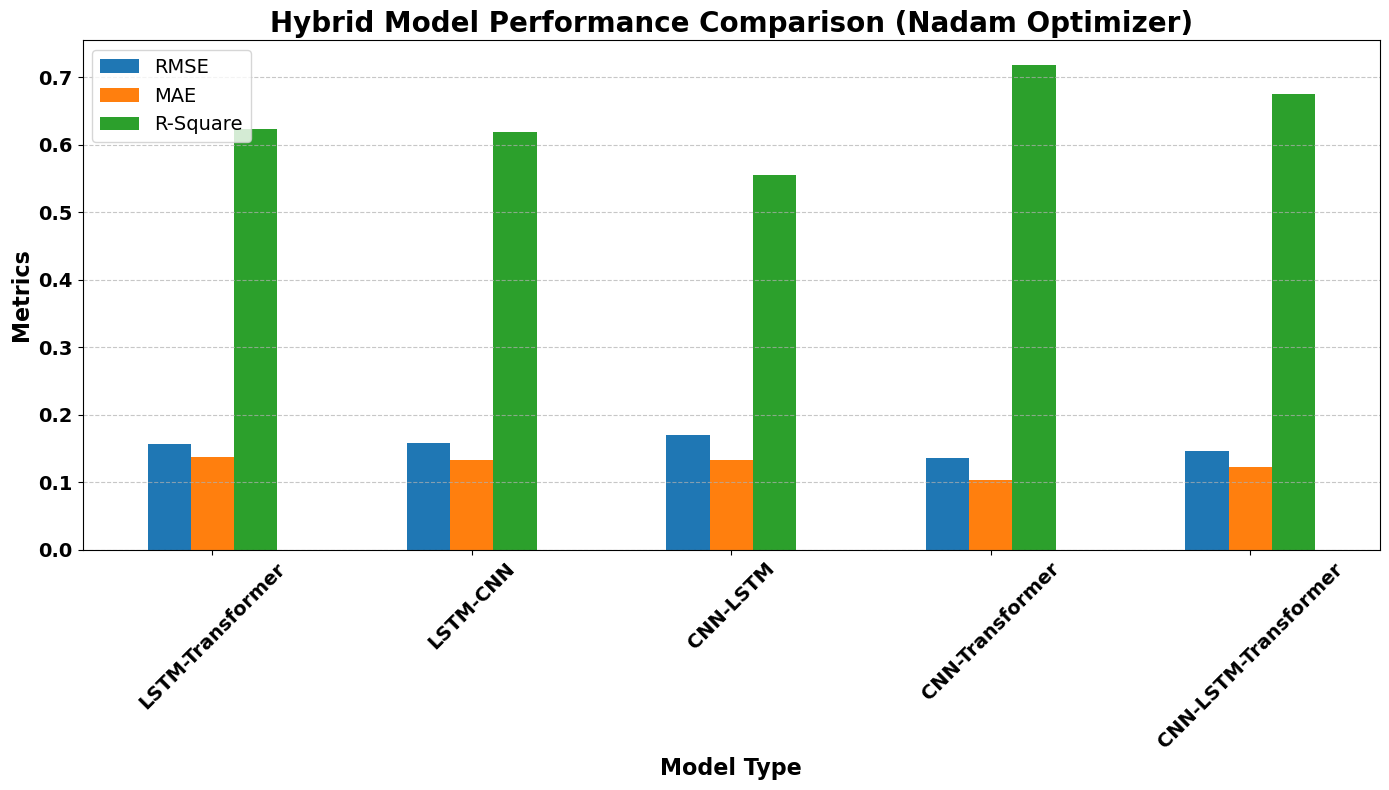

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, Flatten, MultiHeadAttention
from tensorflow.keras.optimizers import Nadam

# Define function to build hybrid models with Nadam optimizer
def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

# Define selected hybrid models
hybrid_models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
]

hybrid_model_names = [
    "LSTM-Transformer", "LSTM-CNN", "CNN-LSTM", "CNN-Transformer", "CNN-LSTM-Transformer"
]

# Evaluate selected hybrid models
hybrid_results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}
for name, model in zip(hybrid_model_names, hybrid_models):
    print(f"Training and evaluating hybrid model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    hybrid_results["Model"].append(name)
    hybrid_results["RMSE"].append(rmse)
    hybrid_results["MAE"].append(mae)
    hybrid_results["R-Square"].append(r2)

# Convert results into DataFrame
hybrid_results_df = pd.DataFrame(hybrid_results)
print(hybrid_results_df)

# Plot hybrid model results with bold and large text
plt.figure(figsize=(14, 8))
hybrid_results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45)
plt.title("Hybrid Model Performance Comparison (Nadam Optimizer)", fontsize=20, fontweight='bold')
plt.ylabel("Metrics", fontsize=16, fontweight='bold')
plt.xlabel("Model Type", fontsize=16, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend(loc="upper left", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Training and evaluating hybrid model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Training and evaluating hybrid model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Training and evaluating hybrid model: Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Training and evaluating hybrid model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Training and evaluating hybrid model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Training and evaluating hybrid model: Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
              Model      RMSE       MAE  R-Square
0  LSTM-Transformer  0.142494  0.128709  0.688648
1          LSTM-CNN  0.162069  0.137075  0.597226
2  Transformer-LSTM  0.112942  0.089490  0.804397
3          CNN-LSTM  0.158729  0.126586  0.613655
4   CNN-Transformer  0.238851  0.186403  0.125186
5   Transformer-CNN  0.142705  0.115118  0.687723


<Figure size 1400x800 with 0 Axes>

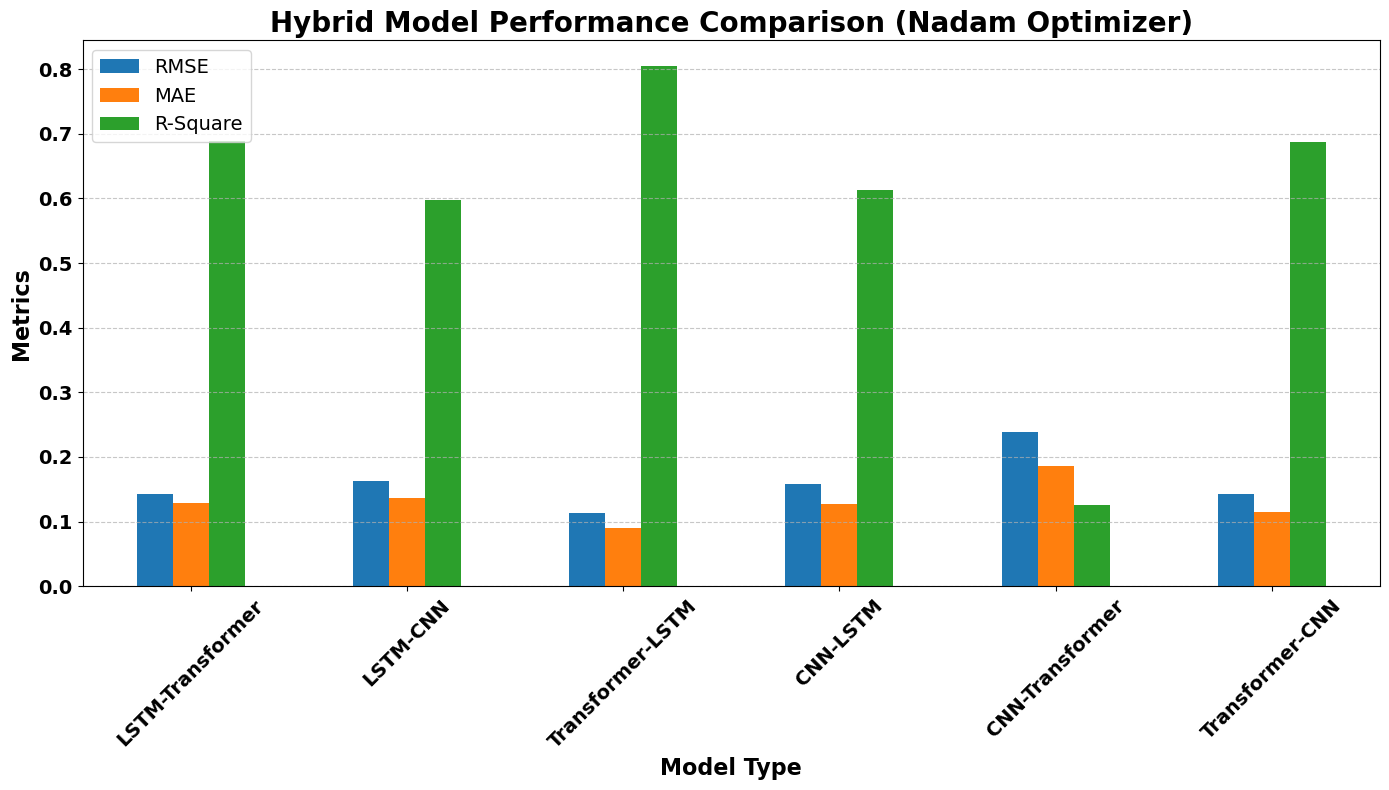

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, Flatten, Reshape, MultiHeadAttention
from tensorflow.keras.optimizers import Nadam

# Define function to build hybrid models with Nadam optimizer
def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

# Define all hybrid models in a list
hybrid_models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_transformer_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_transformer_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn_transformer((X_train_reshaped.shape[1], 1)),
]

hybrid_model_names = [
    "LSTM-Transformer", "LSTM-CNN", "Transformer-LSTM", "CNN-LSTM",
    "CNN-Transformer", "Transformer-CNN", "CNN-LSTM-Transformer", "LSTM-CNN-Transformer"
]

# Evaluate hybrid models
hybrid_results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}
for name, model in zip(hybrid_model_names, hybrid_models):
    print(f"Training and evaluating hybrid model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    hybrid_results["Model"].append(name)
    hybrid_results["RMSE"].append(rmse)
    hybrid_results["MAE"].append(mae)
    hybrid_results["R-Square"].append(r2)

# Convert results into DataFrame
hybrid_results_df = pd.DataFrame(hybrid_results)
print(hybrid_results_df)

# Plot hybrid model results with bold and large text
plt.figure(figsize=(14, 8))
hybrid_results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45)
plt.title("Hybrid Model Performance Comparison (Nadam Optimizer)", fontsize=20, fontweight='bold')
plt.ylabel("Metrics", fontsize=16, fontweight='bold')
plt.xlabel("Model Type", fontsize=16, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend(loc="upper left", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ADAMAX AS AN OPTIMIZER

C:\Users\Ayush\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\Ayush\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training and evaluating model: LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step
Training and evaluating model: CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Training and evaluating model: RNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
Training and evaluating model: Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
         Model      RMSE       MAE  R-Square
0         LSTM  0.188070  0.160814  0.457626
1          CNN  0.231914  0.192995  0.175262
2          RNN  0.034302  0.026951  0.981957
3  Transformer  0.127651  0.103811  0.750131


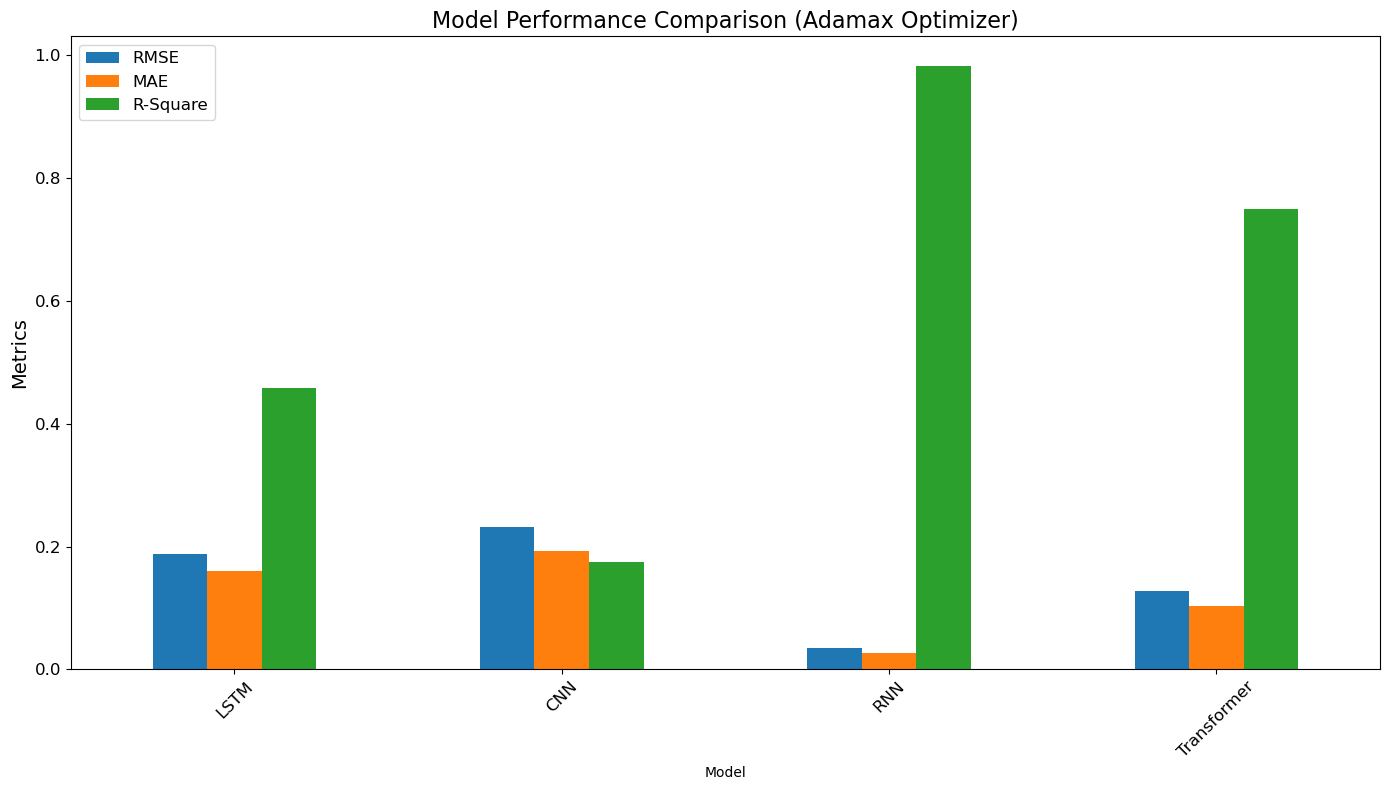

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten, Input, MultiHeadAttention, SimpleRNN
from tensorflow.keras.optimizers import Adamax
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define individual models using Adamax optimizer
def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn(input_shape):
    model = Sequential()
    model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(Flatten())
    model.add(Dense(1))
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_rnn(input_shape):
    model = Sequential()
    model.add(SimpleRNN(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

# Dataset preparation
# Assuming data is preprocessed into X_train_reshaped, y_train, X_test_reshaped, y_test

models = [
    build_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn((X_train_reshaped.shape[1], 1)),
    build_rnn((X_train_reshaped.shape[1], 1)),
    build_transformer((X_train_reshaped.shape[1], 1)),
]

model_names = [
    "LSTM",
    "CNN",
    "RNN",
    "Transformer",
]

# Evaluate models
results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

for name, model in zip(model_names, models):
    print(f"Training and evaluating model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results["Model"].append(name)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    results["R-Square"].append(r2)

# Plotting results
results_df = pd.DataFrame(results)
print(results_df)

# Bar plot for comparison
results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Model Performance Comparison (Adamax Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

## HYBRID

Training and evaluating hybrid model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Training and evaluating hybrid model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Training and evaluating hybrid model: Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Training and evaluating hybrid model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Training and evaluating hybrid model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Training and evaluating hybrid model: Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Training and evaluating hybrid model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Training and evaluating hybrid model: LSTM-CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.213706  0.181463  0.299684
1              LSTM-CNN  0.209965  0.172336  0.323991
2      Transformer-LSTM  0.266536  0.208843 -0.089364
3              CNN-LSTM  0.140637  0.109785  0.696

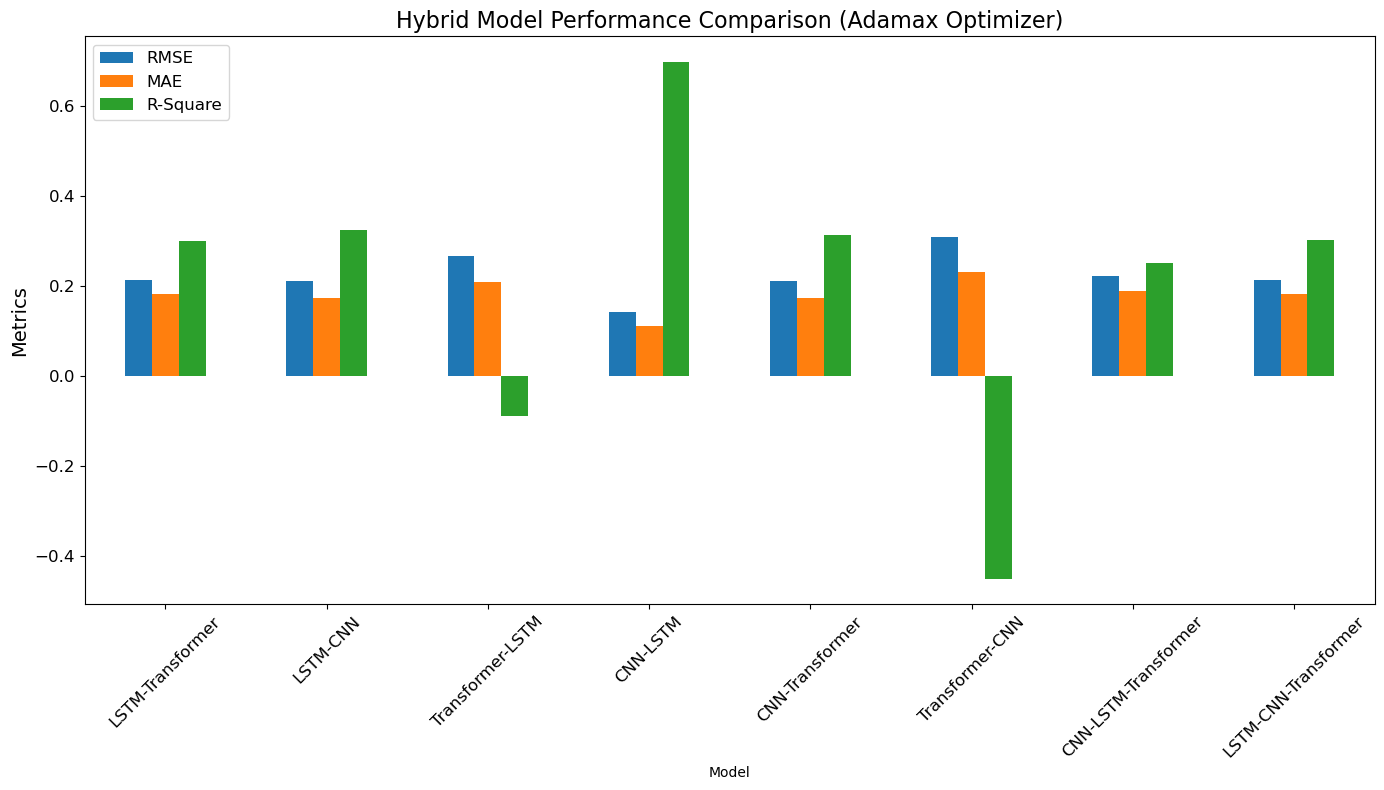

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, Flatten, Reshape, MultiHeadAttention
from tensorflow.keras.optimizers import Adamax

# Define hybrid models with Adamax optimizer

def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    transformer_output = Reshape((transformer_output.shape[1], 1))(transformer_output)
    lstm_output = LSTM(64)(transformer_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(transformer_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

# Define all hybrid models in a list
hybrid_models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_transformer_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_transformer_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn_transformer((X_train_reshaped.shape[1], 1)),
]

hybrid_model_names = [
    "LSTM-Transformer",
    "LSTM-CNN",
    "Transformer-LSTM",
    "CNN-LSTM",
    "CNN-Transformer",
    "Transformer-CNN",
    "CNN-LSTM-Transformer",
    "LSTM-CNN-Transformer",
]

# Evaluate hybrid models
hybrid_results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

for name, model in zip(hybrid_model_names, hybrid_models):
    print(f"Training and evaluating hybrid model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    hybrid_results["Model"].append(name)
    hybrid_results["RMSE"].append(rmse)
    hybrid_results["MAE"].append(mae)
    hybrid_results["R-Square"].append(r2)

# Plotting hybrid model results
hybrid_results_df = pd.DataFrame(hybrid_results)
print(hybrid_results_df)

# Bar plot for comparison
hybrid_results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Hybrid Model Performance Comparison (Adamax Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

In [33]:
import time

# Evaluate hybrid models with computation time tracking
hybrid_results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": [], "Computation Time (s)": []}

for name, model in zip(hybrid_model_names, hybrid_models):
    print(f"Training and evaluating hybrid model: {name}")
    
    start_time = time.time()  # Start time before training
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    end_time = time.time()  # End time after training
    
    computation_time = end_time - start_time  # Compute time taken
    
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    
    hybrid_results["Model"].append(name)
    hybrid_results["RMSE"].append(rmse)
    hybrid_results["MAE"].append(mae)
    hybrid_results["R-Square"].append(r2)
    hybrid_results["Computation Time (s)"].append(computation_time)

# Convert results to DataFrame
hybrid_results_df = pd.DataFrame(hybrid_results)
print(hybrid_results_df)

# Save to CSV if needed
# hybrid_results_df.to_csv("hybrid_model_results.csv", index=False)


Training and evaluating hybrid model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training and evaluating hybrid model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating hybrid model: Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating hybrid model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating hybrid model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step
Training and evaluating hybrid model: Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating hybrid model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training and evaluating hybrid model: LSTM-CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                  Model      RMSE       MAE  R-Square  Computation Time (s)
0      LSTM-Transformer  0.026694  0.023535  0.989073              0.427591
1              LSTM-CNN  0.016977  0.013020  0.995580              0.265166
2      Transformer-LSTM  0.066493  0.055135 

# RMSprop AS AN OPTIMIZER

/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training and evaluating model: LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Training and evaluating model: CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Training and evaluating model: RNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Training and evaluating model: Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
         Model      RMSE       MAE  R-Square
0         LSTM  0.114279  0.096470  0.799741
1          CNN  0.163431  0.135169  0.590431
2          RNN  0.081819  0.056503  0.897348
3  Transformer  0.352439  0.273306 -0.904713


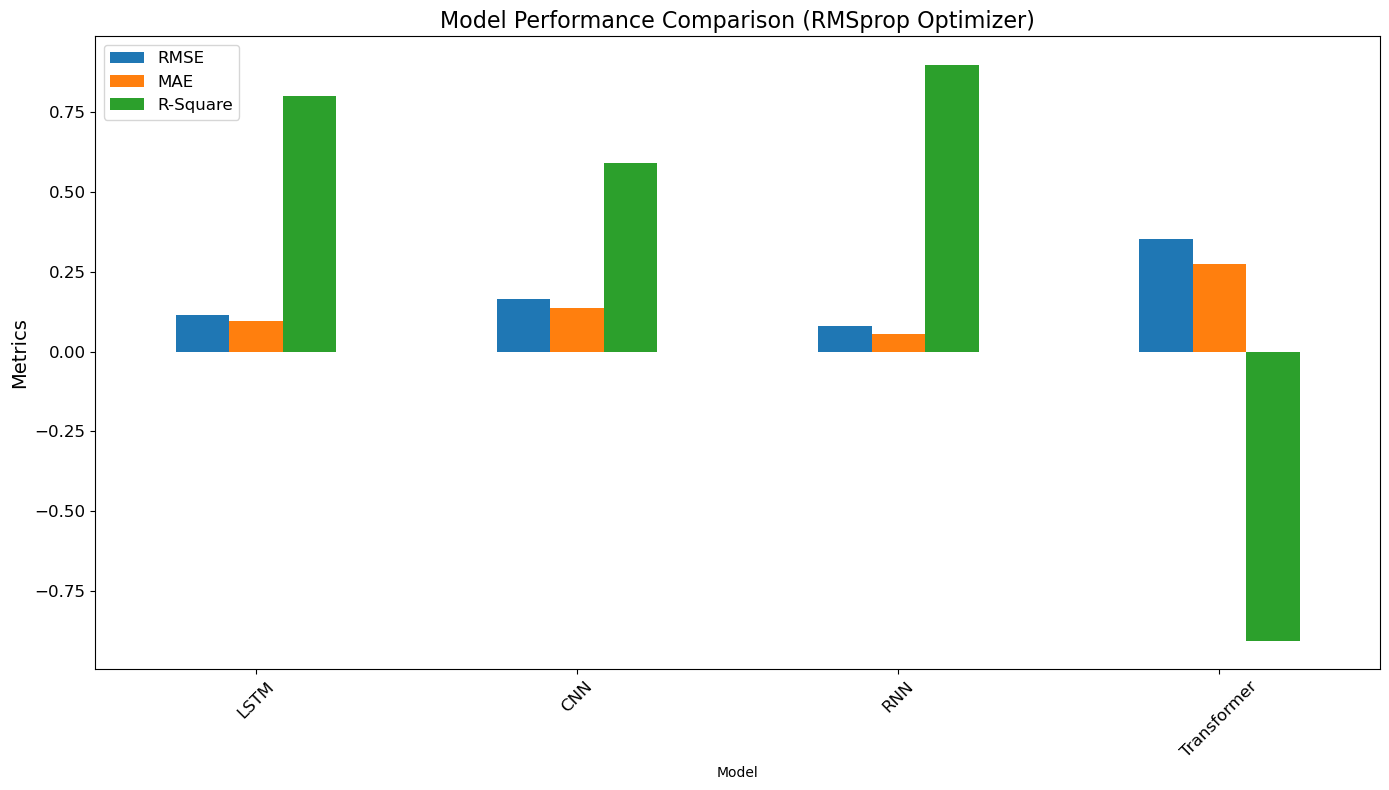

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten, Input, MultiHeadAttention, SimpleRNN
from tensorflow.keras.optimizers import RMSprop
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define individual models using RMSprop optimizer
def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn(input_shape):
    model = Sequential()
    model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(Flatten())
    model.add(Dense(1))
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_rnn(input_shape):
    model = Sequential()
    model.add(SimpleRNN(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

# Dataset preparation
# Assuming data is preprocessed into X_train_reshaped, y_train, X_test_reshaped, y_test

models = [
    build_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn((X_train_reshaped.shape[1], 1)),
    build_rnn((X_train_reshaped.shape[1], 1)),
    build_transformer((X_train_reshaped.shape[1], 1)),
]

model_names = [
    "LSTM",
    "CNN",
    "RNN",
    "Transformer",
]

# Evaluate models
results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

for name, model in zip(model_names, models):
    print(f"Training and evaluating model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results["Model"].append(name)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    results["R-Square"].append(r2)

# Plotting results
results_df = pd.DataFrame(results)
print(results_df)

# Bar plot for comparison
results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Model Performance Comparison (RMSprop Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

## HYBRID

Training and evaluating hybrid model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Training and evaluating hybrid model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Training and evaluating hybrid model: Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Training and evaluating hybrid model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Training and evaluating hybrid model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Training and evaluating hybrid model: Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Training and evaluating hybrid model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Training and evaluating hybrid model: LSTM-CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.192927  0.161939  0.429248
1              LSTM-CNN  0.123959  0.100628  0.764376
2      Transformer-LSTM  0.167209  0.150092  0.571272
3              CNN-LSTM  0.159926  0.139933  0.607

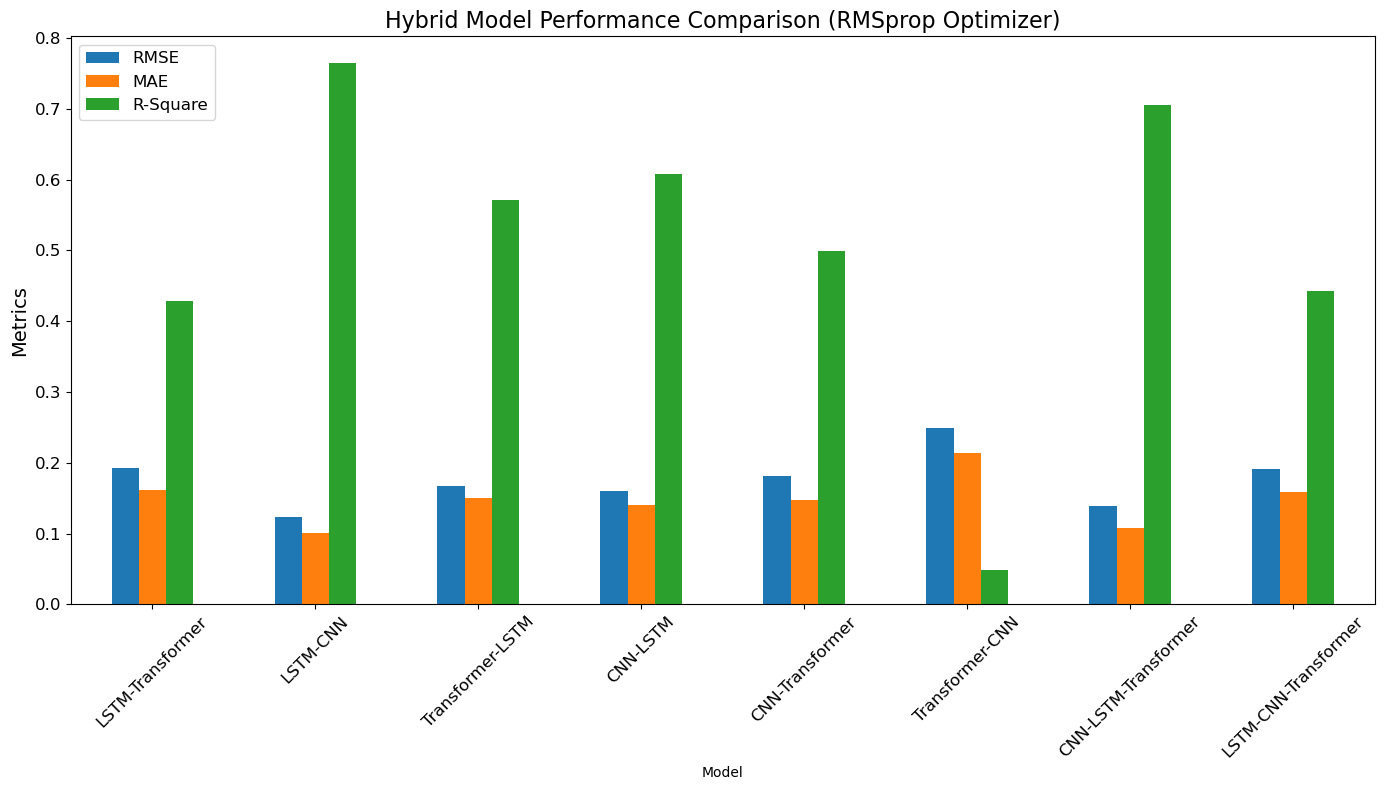

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, Flatten, Reshape, MultiHeadAttention
from tensorflow.keras.optimizers import RMSprop

# Define hybrid models with RMSprop optimizer

def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    transformer_output = Reshape((transformer_output.shape[1], 1))(transformer_output)
    lstm_output = LSTM(64)(transformer_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(transformer_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

# Define all hybrid models
hybrid_models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_transformer_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_transformer_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn_transformer((X_train_reshaped.shape[1], 1)),
]

hybrid_model_names = [
    "LSTM-Transformer",
    "LSTM-CNN",
    "Transformer-LSTM",
    "CNN-LSTM",
    "CNN-Transformer",
    "Transformer-CNN",
    "CNN-LSTM-Transformer",
    "LSTM-CNN-Transformer",
]

# Evaluate hybrid models
hybrid_results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

for name, model in zip(hybrid_model_names, hybrid_models):
    print(f"Training and evaluating hybrid model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    hybrid_results["Model"].append(name)
    hybrid_results["RMSE"].append(rmse)
    hybrid_results["MAE"].append(mae)
    hybrid_results["R-Square"].append(r2)

# Plotting hybrid model results
hybrid_results_df = pd.DataFrame(hybrid_results)
print(hybrid_results_df)

# Bar plot for comparison
hybrid_results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Hybrid Model Performance Comparison (RMSprop Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

In [34]:
import time

# Evaluate hybrid models with computation time tracking
hybrid_results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": [], "Computation Time (s)": []}

for name, model in zip(hybrid_model_names, hybrid_models):
    print(f"Training and evaluating hybrid model: {name}")
    
    start_time = time.time()  # Start time before training
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    end_time = time.time()  # End time after training
    
    computation_time = end_time - start_time  # Compute total time taken
    
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    
    hybrid_results["Model"].append(name)
    hybrid_results["RMSE"].append(rmse)
    hybrid_results["MAE"].append(mae)
    hybrid_results["R-Square"].append(r2)
    hybrid_results["Computation Time (s)"].append(computation_time)

# Convert results to DataFrame
hybrid_results_df = pd.DataFrame(hybrid_results)
print(hybrid_results_df)

# Save to CSV if needed
# hybrid_results_df.to_csv("hybrid_model_results_rmsprop.csv", index=False)


Training and evaluating hybrid model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training and evaluating hybrid model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating hybrid model: Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating hybrid model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating hybrid model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step
Training and evaluating hybrid model: Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating hybrid model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating hybrid model: LSTM-CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                  Model      RMSE       MAE  R-Square  Computation Time (s)
0      LSTM-Transformer  0.024645  0.020246  0.990686              0.437251
1              LSTM-CNN  0.012737  0.010467  0.997512              0.266381
2      Transformer-LSTM  0.054195  0.037588 

# AMSGrad AS AN OPTIMIZER

In [35]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten, Input, SimpleRNN, MultiHeadAttention
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define individual models using Adam(amsgrad=True) optimizer

def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=Adam(amsgrad=True), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn(input_shape):
    model = Sequential()
    model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(Flatten())
    model.add(Dense(1))
    model.compile(optimizer=Adam(amsgrad=True), loss='mean_squared_error', metrics=['mae'])
    return model

def build_rnn(input_shape):
    model = Sequential()
    model.add(SimpleRNN(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=Adam(amsgrad=True), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(amsgrad=True), loss='mean_squared_error', metrics=['mae'])
    return model

# Model Evaluation Function
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Model training and evaluation
results = {
    'Model': [],
    'RMSE': [],
    'MAE': [],
    'R2': []
}

# Iterate over models to train and evaluate
X_train_reshaped = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))  # Adjust shape for models
X_test_reshaped = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))  # Adjust shape for models

for name, model in zip(['LSTM', 'CNN', 'RNN', 'Transformer'], [build_lstm(X_train.shape[1:]), build_cnn(X_train.shape[1:]), build_rnn(X_train.shape[1:]), build_transformer(X_train.shape[1:])]):
    print(f"Training and evaluating model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D

    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results['Model'].append(name)
    results['RMSE'].append(rmse)
    results['MAE'].append(mae)
    results['R2'].append(r2)

# Convert results to a pandas dataframe
import pandas as pd
results_df = pd.DataFrame(results)

# Plotting comparison using clustered bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.25
index = np.arange(len(results_df))

bar1 = ax.bar(index, results_df['RMSE'], bar_width, label='RMSE')
bar2 = ax.bar(index + bar_width, results_df['MAE'], bar_width, label='MAE')
bar3 = ax.bar(index + 2*bar_width, results_df['R2'], bar_width, label='R2')

ax.set_xlabel('Model')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(index + bar_width)
ax.set_xticklabels(results_df['Model'])
ax.legend()

plt.tight_layout()
plt.show()

AttributeError: 'DataFrame' object has no attribute 'reshape'

## HYBRID

In [35]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten, Input, SimpleRNN, MultiHeadAttention
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define hybrid models using Adam(amsgrad=True) optimizer

def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_out = LSTM(64, return_sequences=True)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_out, lstm_out)
    transformer_out = Flatten()(transformer_out)
    outputs = Dense(1)(transformer_out)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(amsgrad=True), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_out = LSTM(64, return_sequences=True)(inputs)
    cnn_out = Conv1D(32, kernel_size=3, activation='relu')(lstm_out)
    cnn_out = Flatten()(cnn_out)
    outputs = Dense(1)(cnn_out)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(amsgrad=True), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_out = Flatten()(transformer_out)
    lstm_out = LSTM(64)(transformer_out)
    outputs = Dense(1)(lstm_out)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(amsgrad=True), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_out = Conv1D(32, kernel_size=3, activation='relu')(inputs)
    cnn_out = Flatten()(cnn_out)
    lstm_out = LSTM(64)(cnn_out)
    outputs = Dense(1)(lstm_out)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(amsgrad=True), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_out = Conv1D(32, kernel_size=3, activation='relu')(inputs)
    cnn_out = Flatten()(cnn_out)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_out, cnn_out)
    transformer_out = Flatten()(transformer_out)
    outputs = Dense(1)(transformer_out)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(amsgrad=True), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_out = Flatten()(transformer_out)
    cnn_out = Conv1D(32, kernel_size=3, activation='relu')(transformer_out)
    cnn_out = Flatten()(cnn_out)
    outputs = Dense(1)(cnn_out)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(amsgrad=True), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_out = Conv1D(32, kernel_size=3, activation='relu')(inputs)
    cnn_out = Flatten()(cnn_out)
    lstm_out = LSTM(64)(cnn_out)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_out, lstm_out)
    transformer_out = Flatten()(transformer_out)
    outputs = Dense(1)(transformer_out)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(amsgrad=True), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_out = LSTM(64, return_sequences=True)(inputs)
    cnn_out = Conv1D(32, kernel_size=3, activation='relu')(lstm_out)
    cnn_out = Flatten()(cnn_out)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_out, cnn_out)
    transformer_out = Flatten()(transformer_out)
    outputs = Dense(1)(transformer_out)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(amsgrad=True), loss='mean_squared_error', metrics=['mae'])
    return model

# Model Evaluation Function
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Model training and evaluation
results = {
    'Model': [],
    'RMSE': [],
    'MAE': [],
    'R2': []
}

X_train_reshaped = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_reshaped = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

for name, model in zip(
    ['LSTM-Transformer', 'LSTM-CNN', 'Transformer-LSTM', 'CNN-LSTM', 'CNN-Transformer', 'Transformer-CNN', 'CNN-LSTM-Transformer', 'LSTM-CNN-Transformer'],
    [build_lstm_transformer(X_train.shape[1:]), build_lstm_cnn(X_train.shape[1:]), build_transformer_lstm(X_train.shape[1:]), build_cnn_lstm(X_train.shape[1:]),
     build_cnn_transformer(X_train.shape[1:]), build_transformer_cnn(X_train.shape[1:]), build_cnn_lstm_transformer(X_train.shape[1:]), build_lstm_cnn_transformer(X_train.shape[1:])]
):
    print(f"Training and evaluating hybrid model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()

    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results['Model'].append(name)
    results['RMSE'].append(rmse)
    results['MAE'].append(mae)
    results['R2'].append(r2)

# Convert results to a pandas dataframe
results_df = pd.DataFrame(results)

# Plotting comparison using clustered bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.25
index = np.arange(len(results_df))

bar1 = ax.bar(index, results_df['RMSE'], bar_width, label='RMSE')
bar2 = ax.bar(index + bar_width, results_df['MAE'], bar_width, label='MAE')
bar3 = ax.bar(index + 2*bar_width, results_df['R2'], bar_width, label='R2')

ax.set_xlabel('Model')
ax.set_ylabel('Scores')
ax.set_title('Hybrid Model Performance Comparison')
ax.set_xticks(index + bar_width)
ax.set_xticklabels(results_df['Model'])
ax.legend()

plt.tight_layout()
plt.show()

AttributeError: 'DataFrame' object has no attribute 'reshape'

# COMPARIOSN BETWEEN BEST AND WORST

## Best (CNN–LSTM with Nadam Optimizer) 

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
RMSE: 0.1149681511720432, MAE: 0.08916634438540012, R²: 0.7973177065835548
dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


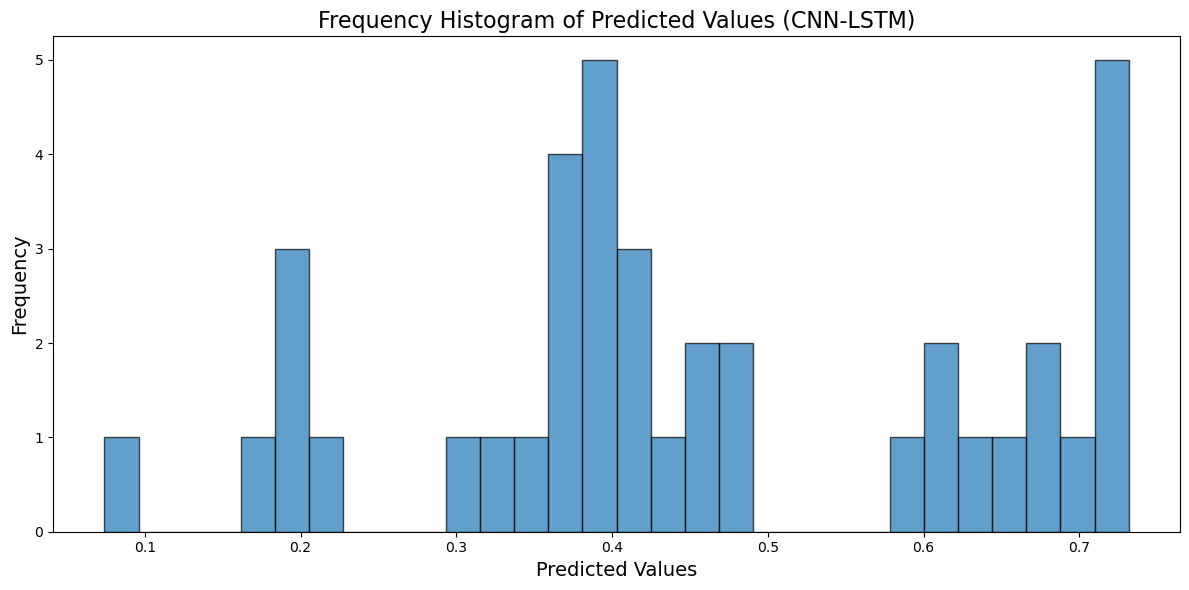

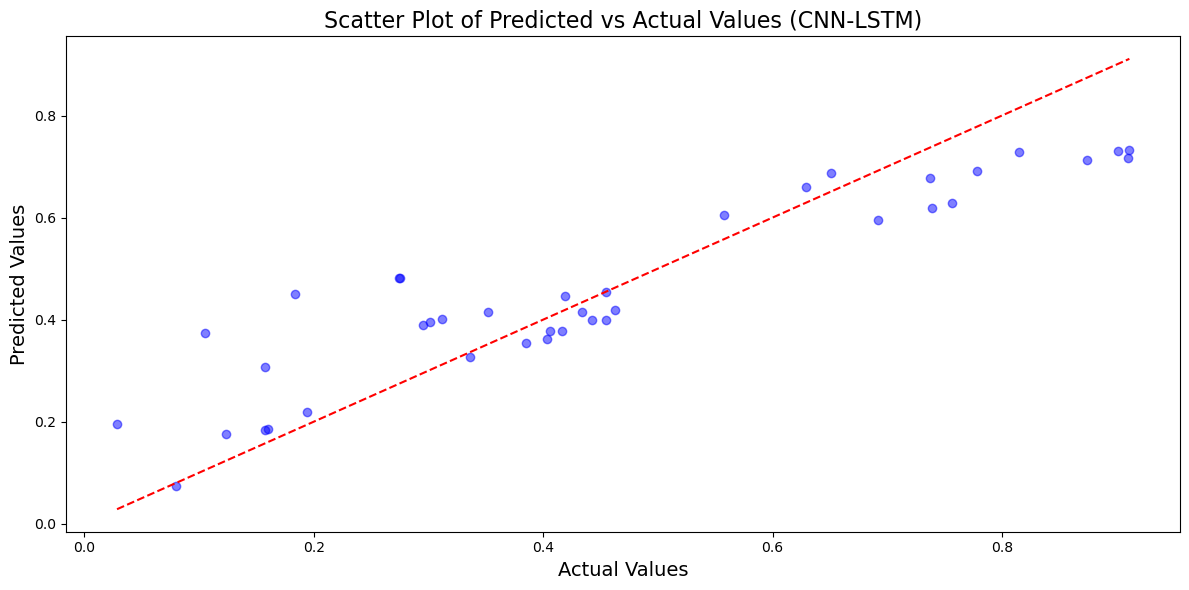

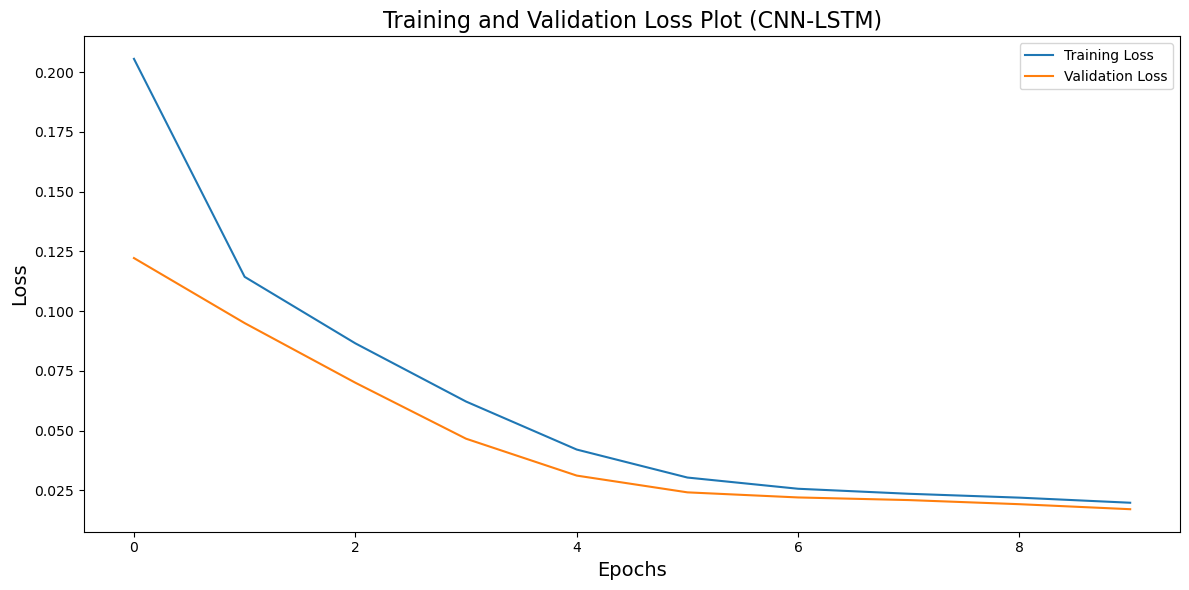

In [36]:
# Train the CNN-LSTM model and track the history
cnn_lstm_model = build_cnn_lstm((X_train_reshaped.shape[1], 1))
history = cnn_lstm_model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)

# Make predictions
y_pred_cnn_lstm = cnn_lstm_model.predict(X_test_reshaped).squeeze()  # Ensure it's 1D

# Calculate metrics (RMSE, MAE, R²)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_cnn_lstm))
mae = mean_absolute_error(y_test, y_pred_cnn_lstm)
r2 = r2_score(y_test, y_pred_cnn_lstm)

print(f"RMSE: {rmse}, MAE: {mae}, R²: {r2}")

# Check the keys in the history object
print(history.history.keys())  # This will display available metrics in the history

# a) Frequency Histogram of Predicted Values
plt.figure(figsize=(12, 6))
plt.hist(y_pred_cnn_lstm, bins=30, edgecolor='black', alpha=0.7)
plt.title('Frequency Histogram of Predicted Values (CNN-LSTM)', fontsize=16)
plt.xlabel('Predicted Values', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.tight_layout()
plt.show()

# b) Scatter Plot of Predicted vs Actual Values
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred_cnn_lstm, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Perfect prediction line
plt.title('Scatter Plot of Predicted vs Actual Values (CNN-LSTM)', fontsize=16)
plt.xlabel('Actual Values', fontsize=14)
plt.ylabel('Predicted Values', fontsize=14)
plt.tight_layout()
plt.show()

# c) Training and Validation Loss Plot
# Check if 'loss' and 'val_loss' exist in the history
if 'loss' in history.history and 'val_loss' in history.history:
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss Plot (CNN-LSTM)', fontsize=16)
    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Training and validation loss are not available in the history. Check the model training setup.")

## Worst Model (Transformer–CNN with Adamax Optimizer)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


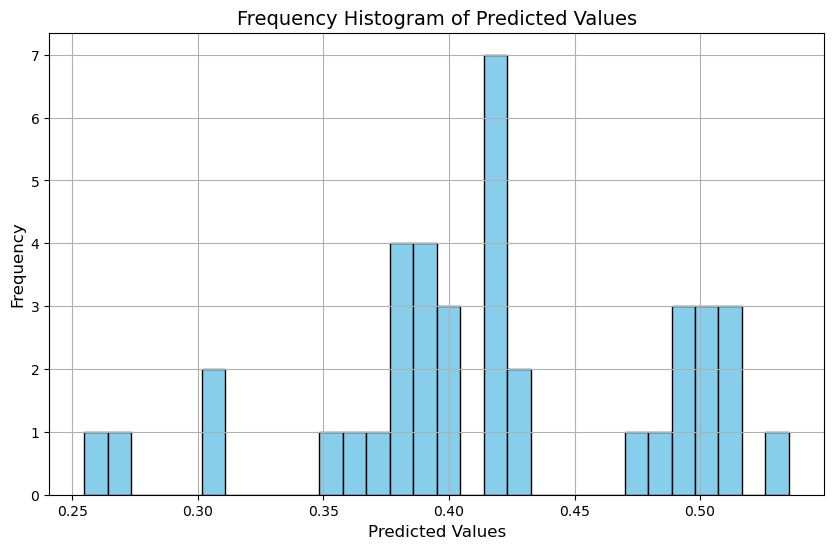

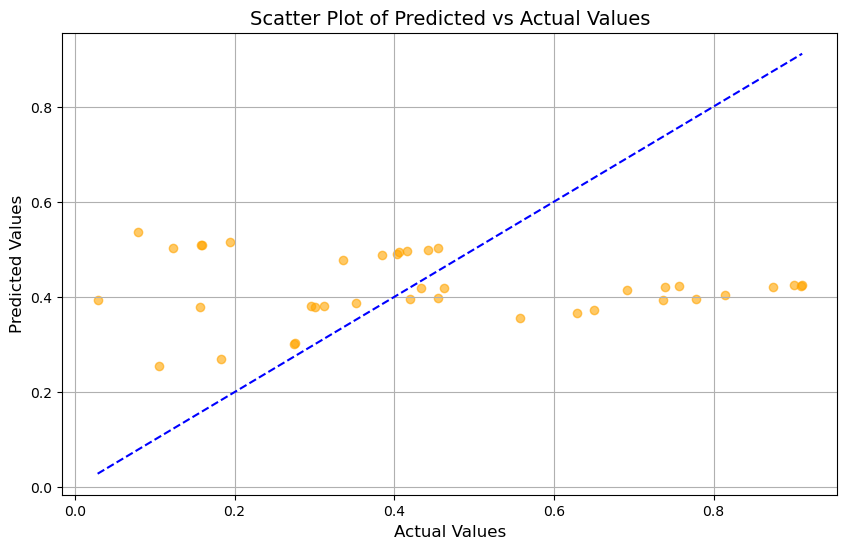

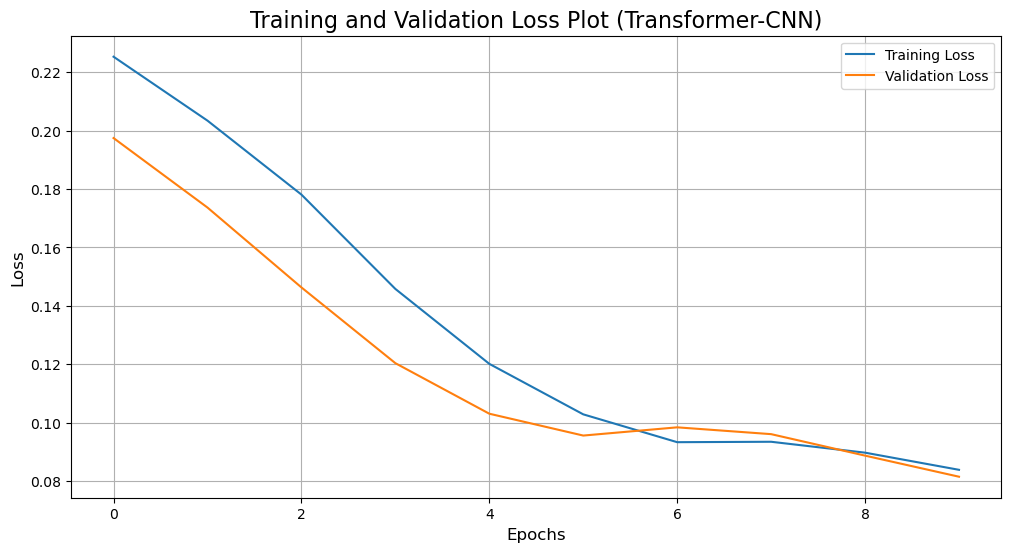

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Define the Transformer-CNN model
def build_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(transformer_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

# Train the model
model = build_transformer_cnn((X_train_reshaped.shape[1], 1))  # Assuming X_train_reshaped is defined
history = model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)

# Make predictions
y_pred = model.predict(X_test_reshaped)  # Assuming X_test_reshaped is defined
y_pred = y_pred.squeeze()  # Ensure y_pred is 1D

# 1. Frequency Histogram of Predicted Values
plt.figure(figsize=(10, 6))
plt.hist(y_pred, bins=30, color='skyblue', edgecolor='black')
plt.title('Frequency Histogram of Predicted Values', fontsize=14)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True)
plt.show()

# 2. Scatter Plot of Predicted vs. Actual Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='orange', alpha=0.6)
plt.title('Scatter Plot of Predicted vs Actual Values', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='blue', linestyle='--')  # Identity line
plt.grid(True)
plt.show()

# 3. Training and Validation Loss Plot
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Plot (Transformer-CNN)', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# EDA

### HEATMAP

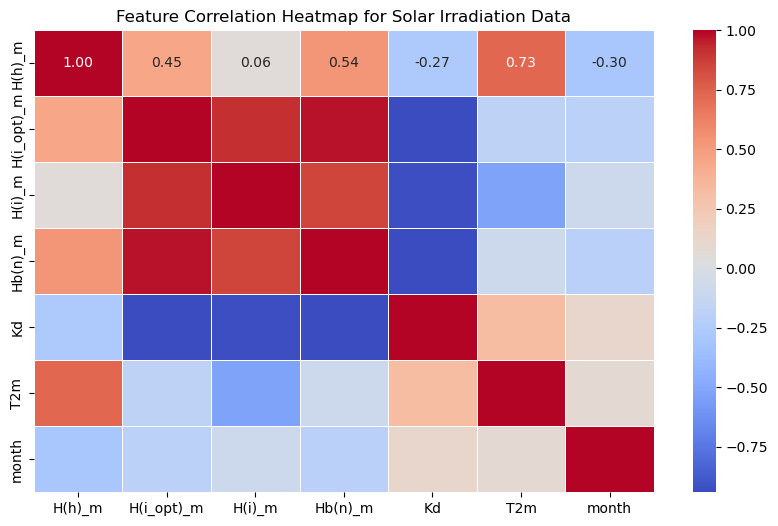

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('solar_radiation (1).csv')

# Convert categorical 'month' column to numeric (if not already done)
month_mapping = {month: idx for idx, month in enumerate(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])}
data['month'] = data['month'].map(month_mapping)

# Selecting only numerical columns for correlation analysis
numerical_features = ['H(h)_m', 'H(i_opt)_m', 'H(i)_m', 'Hb(n)_m', 'Kd', 'T2m', 'month']
df_numeric = data[numerical_features]

# Compute correlation matrix
corr_matrix = df_numeric.corr()

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap for Solar Irradiation Data")
plt.show()


### 2) Scatter plot

C:\Users\Ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

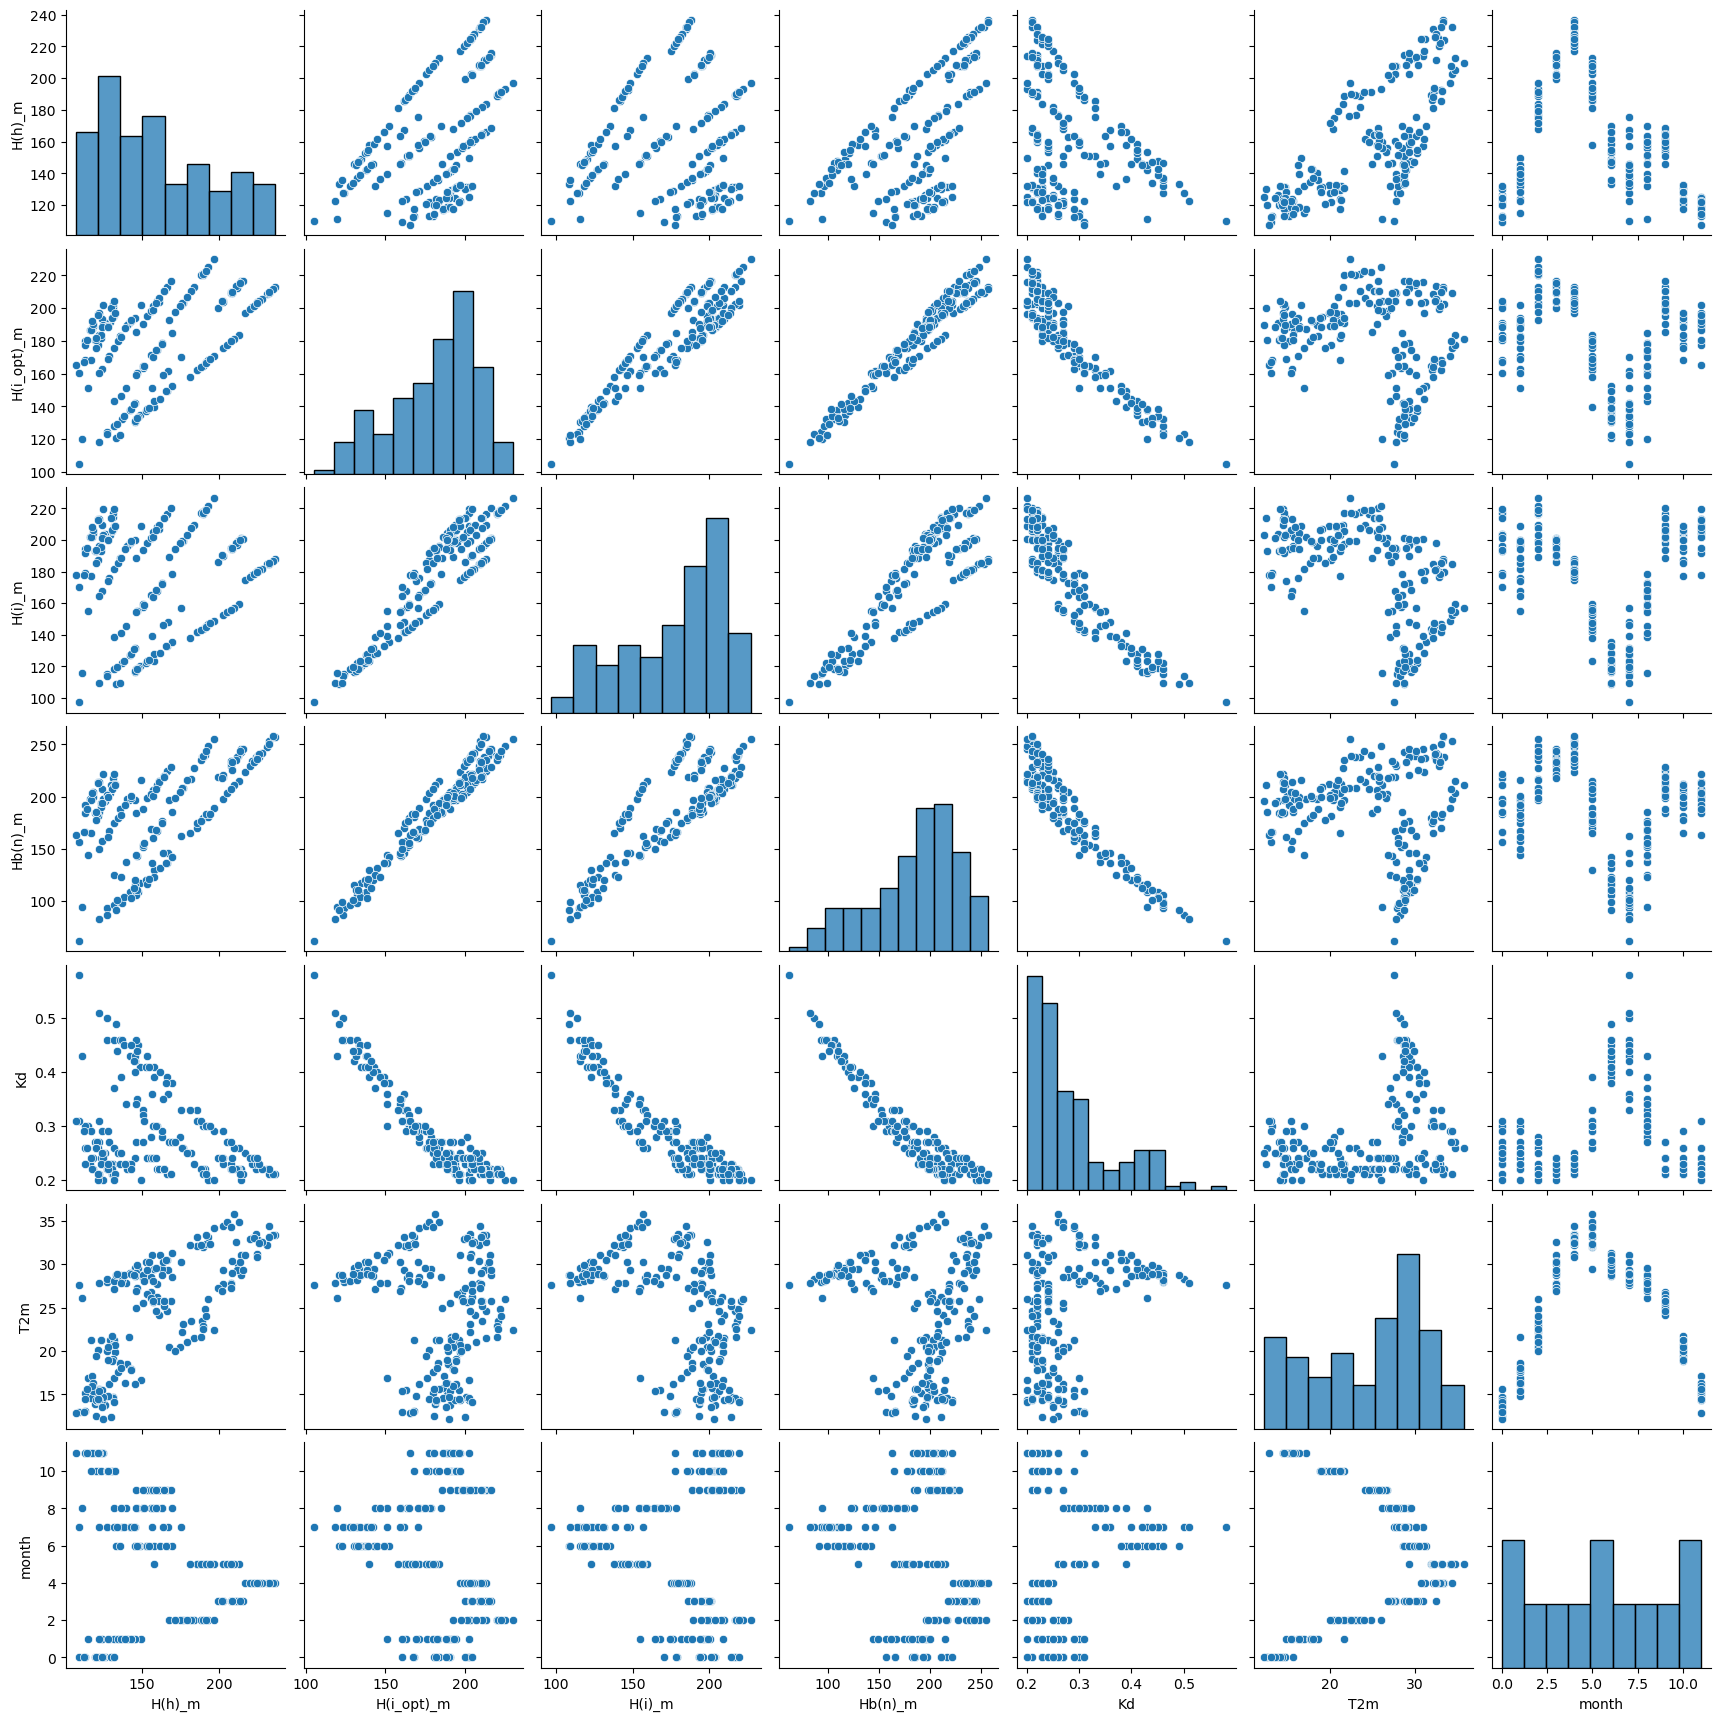

<Figure size 640x480 with 0 Axes>

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(data[['H(h)_m', 'H(i_opt)_m', 'H(i)_m', 'Hb(n)_m', 'Kd', 'T2m', 'month']])
plt.show()

plt.savefig("scatterplot.png", dpi=300, bbox_inches='tight')


### 3) box plot

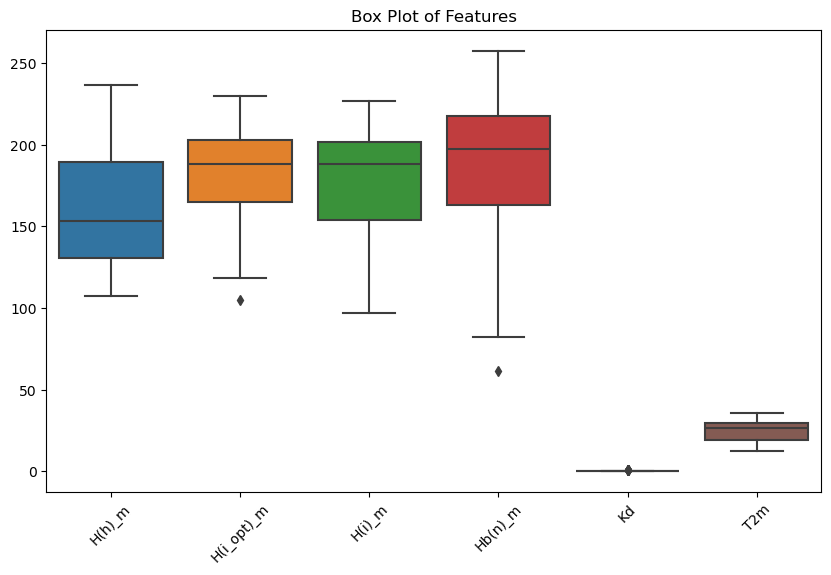

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data[['H(h)_m', 'H(i_opt)_m', 'H(i)_m', 'Hb(n)_m', 'Kd', 'T2m']])
plt.xticks(rotation=45)
plt.title("Box Plot of Features")
plt.show()


### 3) time series plot

C:\Users\Ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

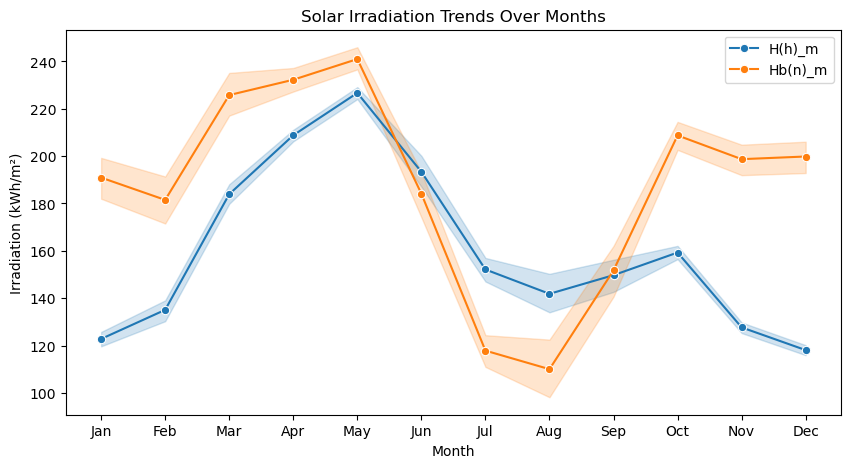

In [12]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=data['month'], y=data['H(h)_m'], marker='o', label='H(h)_m')
sns.lineplot(x=data['month'], y=data['Hb(n)_m'], marker='o', label='Hb(n)_m')
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title("Solar Irradiation Trends Over Months")
plt.xlabel("Month")
plt.ylabel("Irradiation (kWh/m²)")
plt.legend()
plt.show()

In [45]:
print(corr_matrix)

              H(h)_m  H(i_opt)_m    H(i)_m   Hb(n)_m        Kd       T2m  \
H(h)_m      1.000000    0.450843  0.055460  0.536072 -0.272056  0.731999   
H(i_opt)_m  0.450843    1.000000  0.916219  0.975473 -0.939142 -0.176578   
H(i)_m      0.055460    0.916219  1.000000  0.850411 -0.927853 -0.526034   
Hb(n)_m     0.536072    0.975473  0.850411  1.000000 -0.941287 -0.087488   
Kd         -0.272056   -0.939142 -0.927853 -0.941287  1.000000  0.321765   
T2m         0.731999   -0.176578 -0.526034 -0.087488  0.321765  1.000000   
month      -0.302300   -0.197632 -0.084837 -0.201783  0.119160  0.083609   

               month  
H(h)_m     -0.302300  
H(i_opt)_m -0.197632  
H(i)_m     -0.084837  
Hb(n)_m    -0.201783  
Kd          0.119160  
T2m         0.083609  
month       1.000000  


### MANUSCRIPT CHANGES

CNN - MAE: 0.00867896554547489, R2: 0.997677813795225, RMSE: 0.012306035480256904
LSTM - MAE: 0.15546862817988838, R2: 0.4787264681978983, RMSE: 0.18437518937203326
Transformer - MAE: 0.021941340442082093, R2: 0.9888375774145103, RMSE: 0.026980430344455016


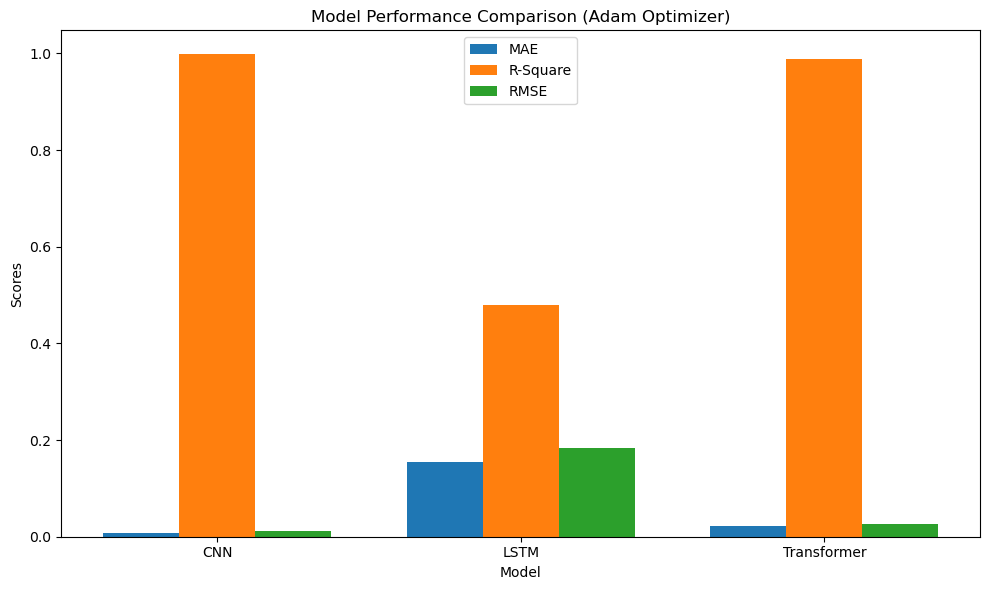

In [85]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Calculate RMSE
    return mae, r2, rmse

# Calculate evaluation metrics for each model
mae_cnn, r2_cnn, rmse_cnn = evaluate_model(y_test, y_pred_cnn)
mae_lstm, r2_lstm, rmse_lstm = evaluate_model(y_test, y_pred_lstm)
mae_transformer, r2_transformer, rmse_transformer = evaluate_model(y_test, y_pred)

# Print results
print(f"CNN - MAE: {mae_cnn}, R2: {r2_cnn}, RMSE: {rmse_cnn}")
print(f"LSTM - MAE: {mae_lstm}, R2: {r2_lstm}, RMSE: {rmse_lstm}")
print(f"Transformer - MAE: {mae_transformer}, R2: {r2_transformer}, RMSE: {rmse_transformer}")

# Data for bar graph
models = ['CNN', 'LSTM', 'Transformer']
mae_values = [mae_cnn, mae_lstm, mae_transformer]
r2_values = [r2_cnn, r2_lstm, r2_transformer]
rmse_values = [rmse_cnn, rmse_lstm, rmse_transformer]

# Plotting the bar chart
x = np.arange(len(models))  # The label locations
width = 0.25  # The width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart for MAE, R2, and RMSE
rects1 = ax.bar(x - width, mae_values, width, label='MAE')
rects2 = ax.bar(x, r2_values, width, label='R-Square')
rects3 = ax.bar(x + width, rmse_values, width, label='RMSE')

# Add some text for labels, title, and custom x-axis tick labels
ax.set_xlabel('Model')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison (Adam Optimizer)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Show the bar chart
plt.tight_layout()
plt.show()

## HYBRID COMPARSISONS

Training and evaluating model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 322ms/step
Training and evaluating model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Training and evaluating model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
Training and evaluating model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Training and evaluating model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.199743  0.165006  0.388210
1              LSTM-CNN  0.179554  0.152168  0.505633
2              CNN-LSTM  0.202775  0.164462  0.369494
3       CNN-Transformer  0.208295  0.176192  0.334700
4  CNN-LSTM-Transformer  0.213900  0.177587  0.298414


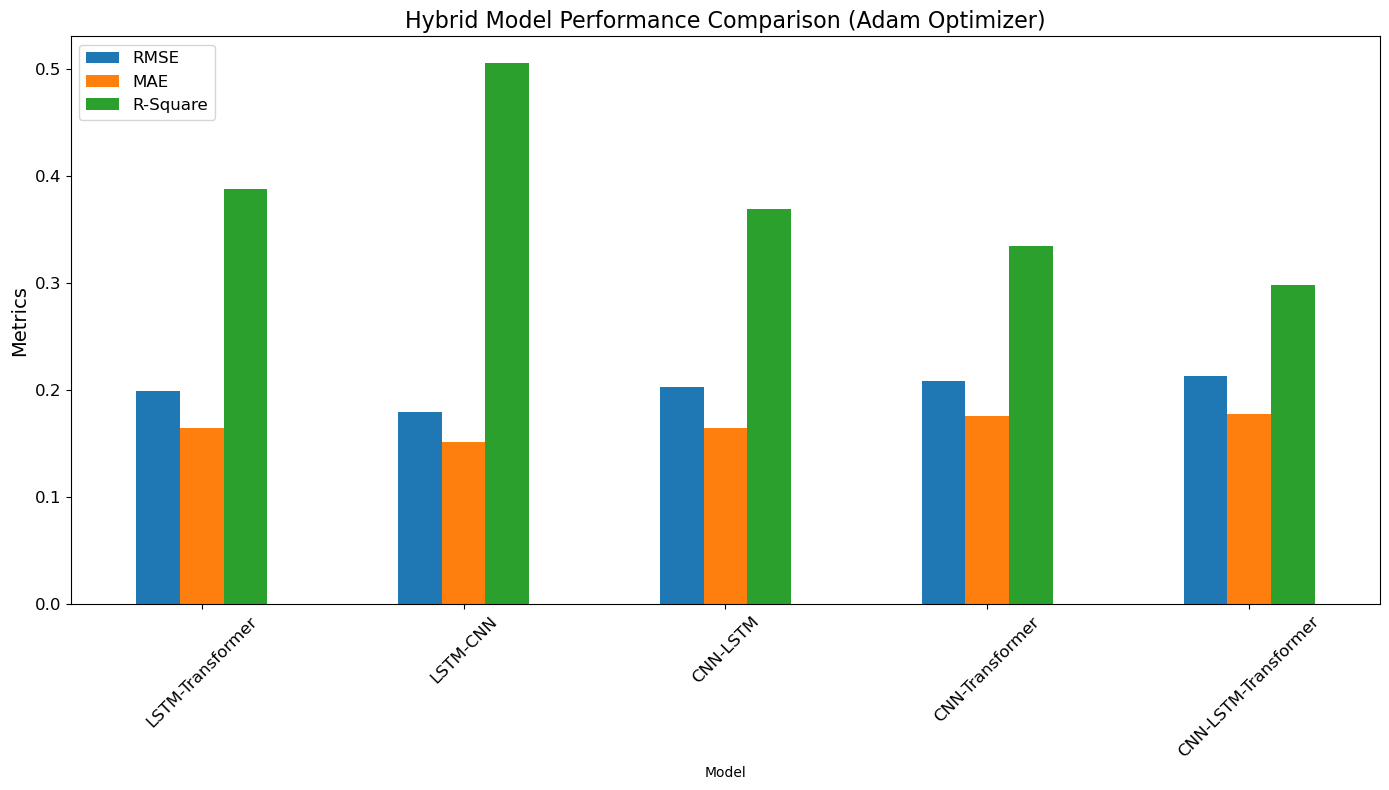

In [86]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Conv1D, Flatten, Reshape, Dropout, LayerNormalization, MultiHeadAttention
)
from tensorflow.keras.optimizers import Adam

# Define hybrid models
def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

# Dataset preparation
# Assuming data is preprocessed into X_train_reshaped, y_train, X_test_reshaped, y_test

# Define models and their names
models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
]

model_names = [
    "LSTM-Transformer",
    "LSTM-CNN",
    "CNN-LSTM",
    "CNN-Transformer",
    "CNN-LSTM-Transformer",
]

# Evaluate models
results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

for name, model in zip(model_names, models):
    print(f"Training and evaluating model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results["Model"].append(name)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    results["R-Square"].append(r2)

# Plotting results
results_df = pd.DataFrame(results)
print(results_df)

# Bar plot for comparison
results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Hybrid Model Performance Comparison (Adam Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

## NADAM OPTIMISER

C:\Users\Ayush\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\Ayush\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training and evaluating model: LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
Training and evaluating model: CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Training and evaluating model: Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
         Model      RMSE       MAE  R-Square
0         LSTM  0.202781  0.170247  0.369455
1          CNN  0.179260  0.155319  0.507251
2  Transformer  0.188954  0.156056  0.452514


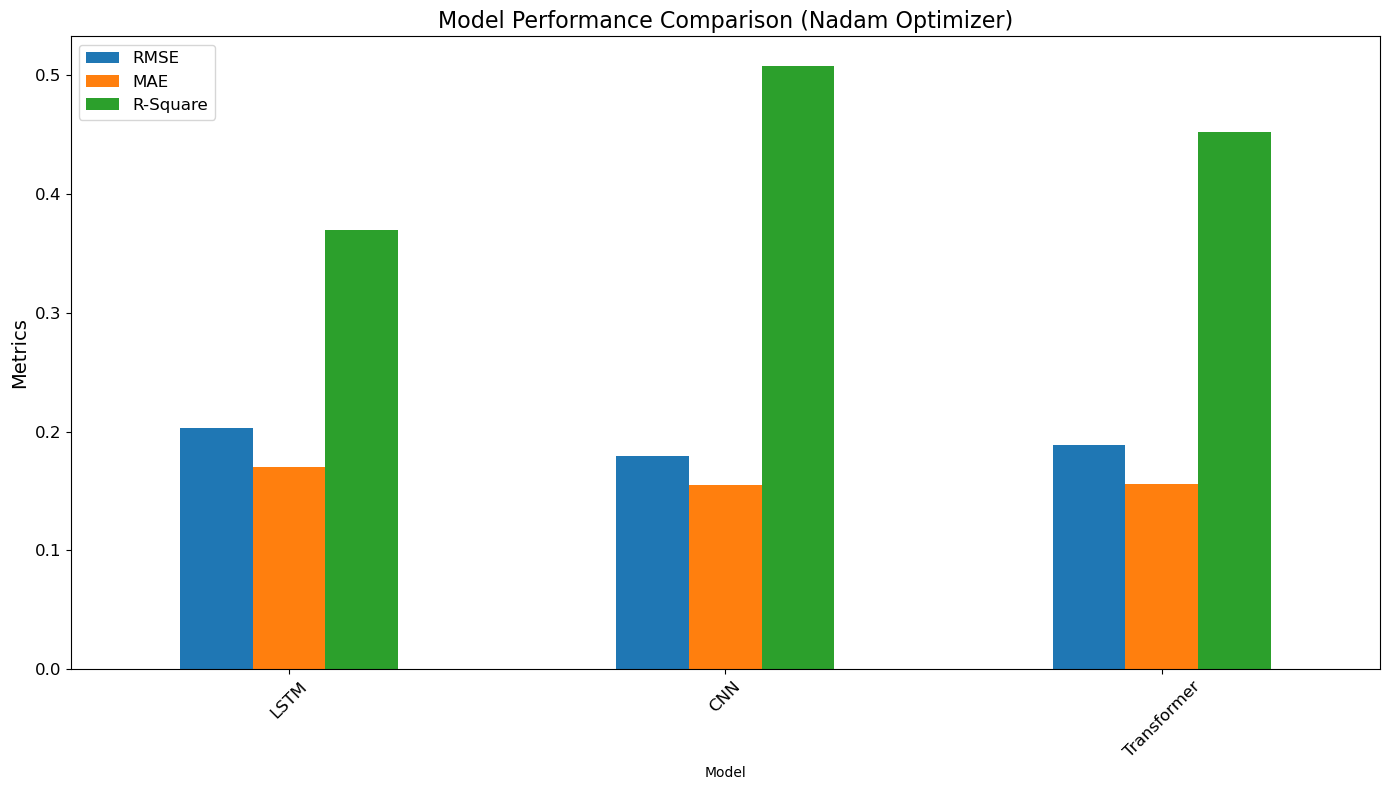

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten, Input, MultiHeadAttention, Reshape
from tensorflow.keras.optimizers import Nadam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define individual models using Nadam optimizer
def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn(input_shape):
    model = Sequential()
    model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(Flatten())
    model.add(Dense(1))
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

# Dataset preparation
# Assuming data is preprocessed into X_train_reshaped, y_train, X_test_reshaped, y_test

models = [
    build_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn((X_train_reshaped.shape[1], 1)),
    build_transformer((X_train_reshaped.shape[1], 1)),
]

model_names = [
    "LSTM",
    "CNN",
    "Transformer",
]

# Evaluate models
results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

for name, model in zip(model_names, models):
    print(f"Training and evaluating model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results["Model"].append(name)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    results["R-Square"].append(r2)

# Plotting results
results_df = pd.DataFrame(results)
print(results_df)

# Bar plot for comparison
results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Model Performance Comparison (Nadam Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

### HYBRID

Training and evaluating hybrid model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step
Training and evaluating hybrid model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
Training and evaluating hybrid model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
Training and evaluating hybrid model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Training and evaluating hybrid model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 266ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.172023  0.152129  0.546231
1              LSTM-CNN  0.190774  0.164104  0.441917
2              CNN-LSTM  0.201857  0.168837  0.375190
3       CNN-Transformer  0.203319  0.175608  0.366109
4  CNN-LSTM-Transformer  0.193718  0.163873  0.424562


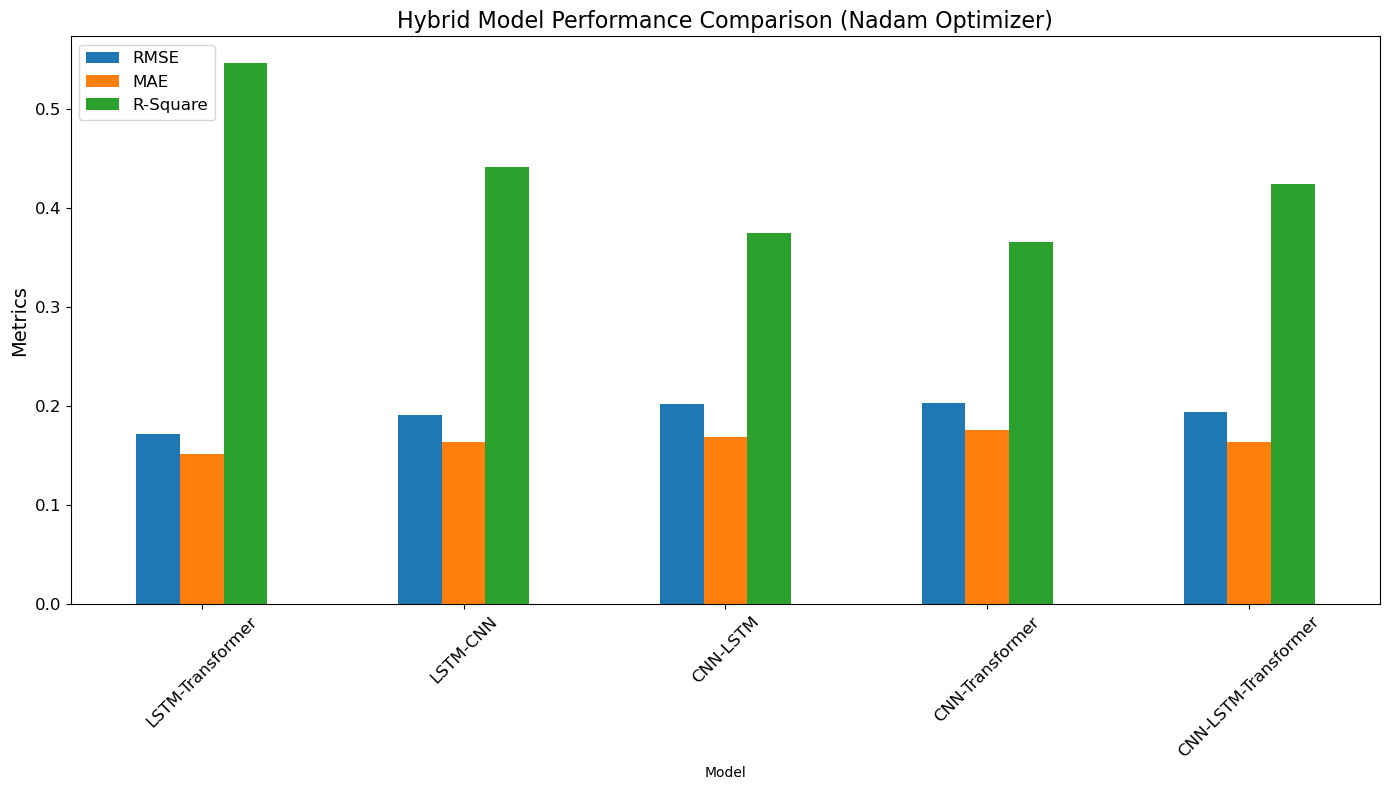

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, Flatten, Reshape, MultiHeadAttention
from tensorflow.keras.optimizers import Nadam

# Define hybrid models with Nadam optimizer

def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model


# Define all hybrid models in a list
hybrid_models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
]

hybrid_model_names = [
    "LSTM-Transformer",
    "LSTM-CNN",
    "CNN-LSTM",
    "CNN-Transformer",
    "CNN-LSTM-Transformer",
]

# Evaluate hybrid models
hybrid_results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

for name, model in zip(hybrid_model_names, hybrid_models):
    print(f"Training and evaluating hybrid model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    hybrid_results["Model"].append(name)
    hybrid_results["RMSE"].append(rmse)
    hybrid_results["MAE"].append(mae)
    hybrid_results["R-Square"].append(r2)

# Plotting hybrid model results
hybrid_results_df = pd.DataFrame(hybrid_results)
print(hybrid_results_df)

# Bar plot for comparison
hybrid_results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Hybrid Model Performance Comparison (Nadam Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

## ADAMAX

C:\Users\Ayush\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\Ayush\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training and evaluating model: LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
Training and evaluating model: CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Training and evaluating model: Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
         Model      RMSE       MAE  R-Square
0         LSTM  0.197270  0.164814  0.403266
1          CNN  0.353909  0.272977 -0.920631
2  Transformer  0.206058  0.169403  0.348911


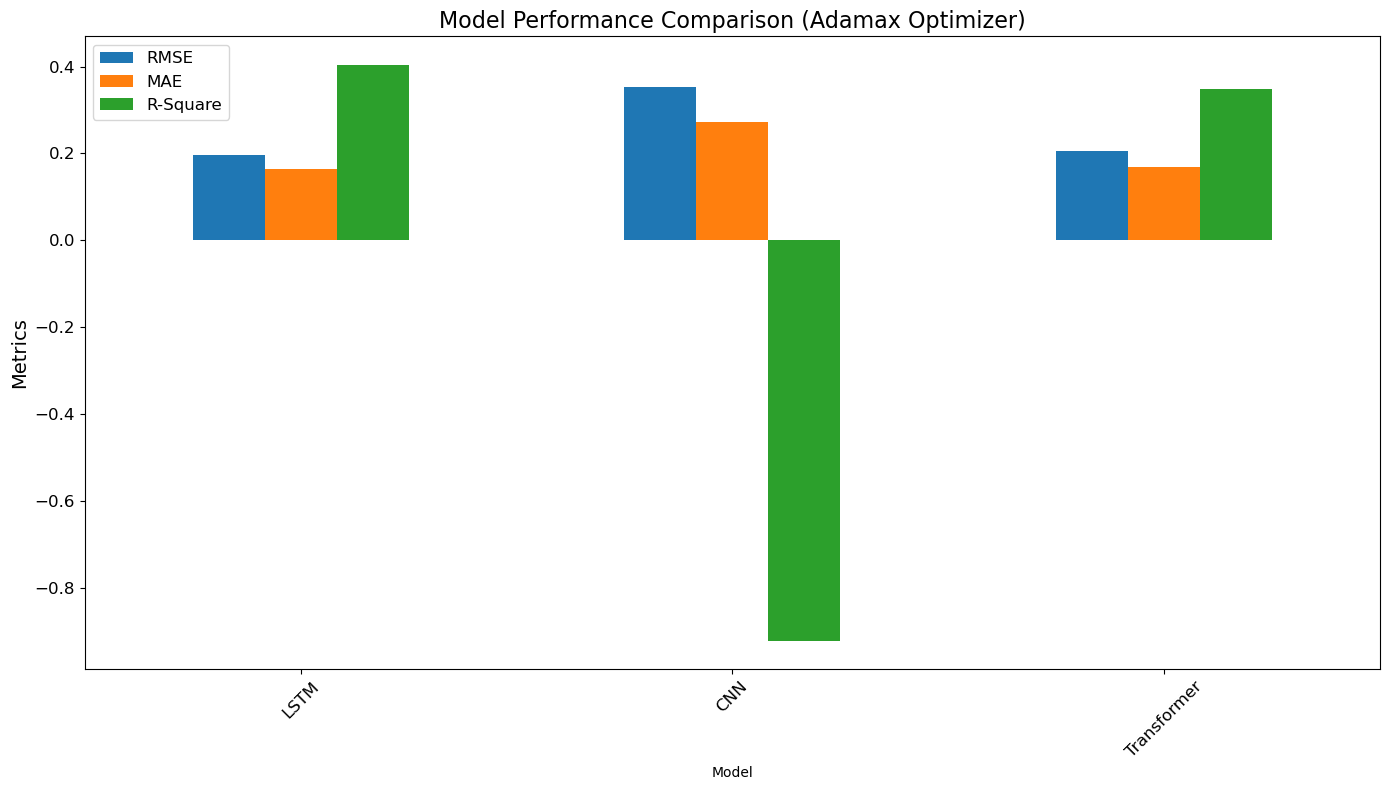

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten, Input, MultiHeadAttention, SimpleRNN
from tensorflow.keras.optimizers import Adamax
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define individual models using Adamax optimizer
def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn(input_shape):
    model = Sequential()
    model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(Flatten())
    model.add(Dense(1))
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

# Dataset preparation
# Assuming data is preprocessed into X_train_reshaped, y_train, X_test_reshaped, y_test

models = [
    build_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn((X_train_reshaped.shape[1], 1)),
    build_transformer((X_train_reshaped.shape[1], 1)),
]

model_names = [
    "LSTM",
    "CNN",
    "Transformer",
]

# Evaluate models
results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

for name, model in zip(model_names, models):
    print(f"Training and evaluating model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results["Model"].append(name)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    results["R-Square"].append(r2)

# Plotting results
results_df = pd.DataFrame(results)
print(results_df)

# Bar plot for comparison
results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Model Performance Comparison (Adamax Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

### HYBRID

Training and evaluating hybrid model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step
Training and evaluating hybrid model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
Training and evaluating hybrid model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
Training and evaluating hybrid model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Training and evaluating hybrid model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.194256  0.163116  0.421361
1              LSTM-CNN  0.193912  0.164035  0.423406
2              CNN-LSTM  0.209320  0.173926  0.328132
3       CNN-Transformer  0.221973  0.180436  0.244456
4  CNN-LSTM-Transformer  0.227042  0.185506  0.209552


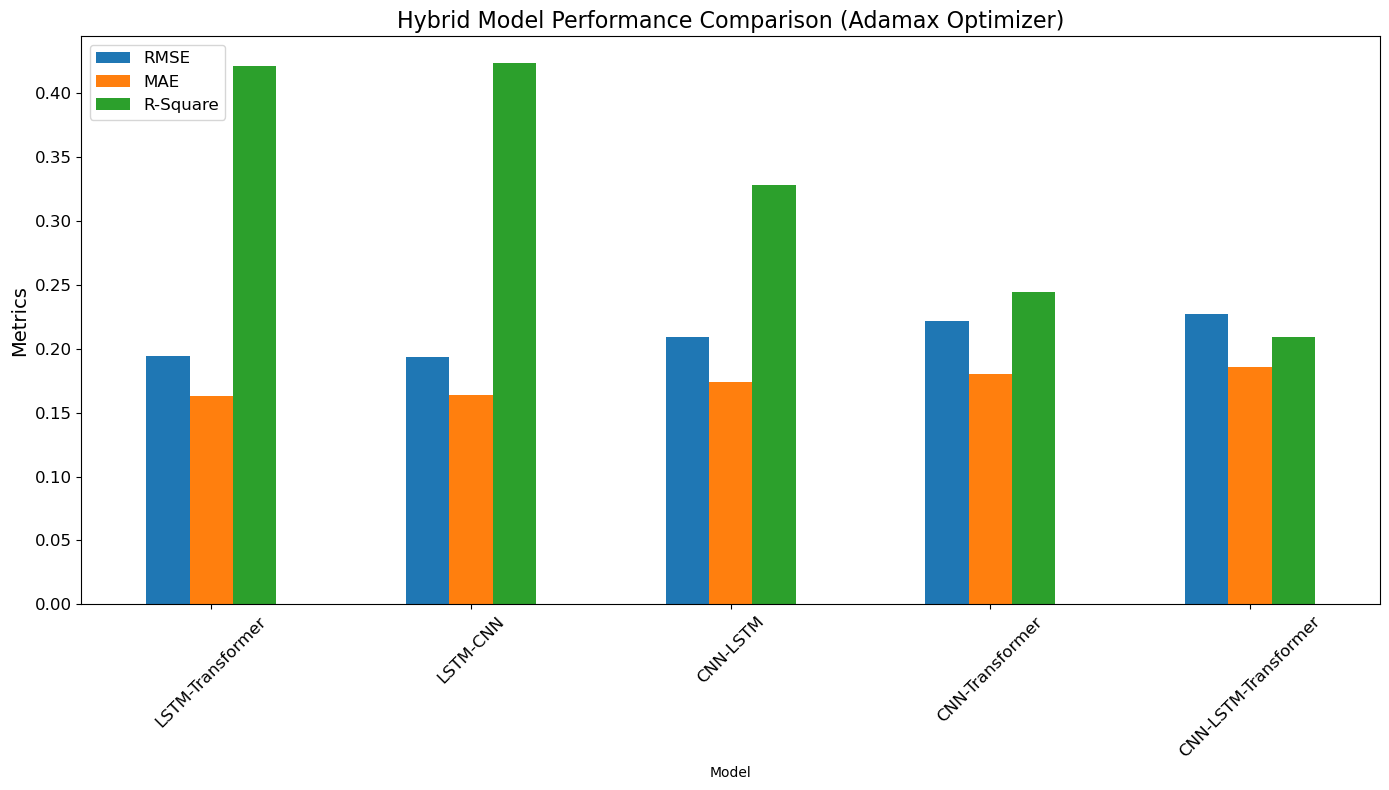

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, Flatten, Reshape, MultiHeadAttention
from tensorflow.keras.optimizers import Adamax

# Define hybrid models with Adamax optimizer

def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model


def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model



# Define all hybrid models in a list
hybrid_models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
]

hybrid_model_names = [
    "LSTM-Transformer",
    "LSTM-CNN",
    "CNN-LSTM",
    "CNN-Transformer",
    "CNN-LSTM-Transformer",
]

# Evaluate hybrid models
hybrid_results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

for name, model in zip(hybrid_model_names, hybrid_models):
    print(f"Training and evaluating hybrid model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    hybrid_results["Model"].append(name)
    hybrid_results["RMSE"].append(rmse)
    hybrid_results["MAE"].append(mae)
    hybrid_results["R-Square"].append(r2)

# Plotting hybrid model results
hybrid_results_df = pd.DataFrame(hybrid_results)
print(hybrid_results_df)

# Bar plot for comparison
hybrid_results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Hybrid Model Performance Comparison (Adamax Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

Training and evaluating hybrid model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
Training and evaluating hybrid model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
Training and evaluating hybrid model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
Training and evaluating hybrid model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Training and evaluating hybrid model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.196932  0.165226  0.405304
1              LSTM-CNN  0.194071  0.162432  0.422462
2              CNN-LSTM  0.206285  0.169871  0.347478
3       CNN-Transformer  0.209134  0.174445  0.329326
4  CNN-LSTM-Transformer  0.206471  0.172704  0.346300


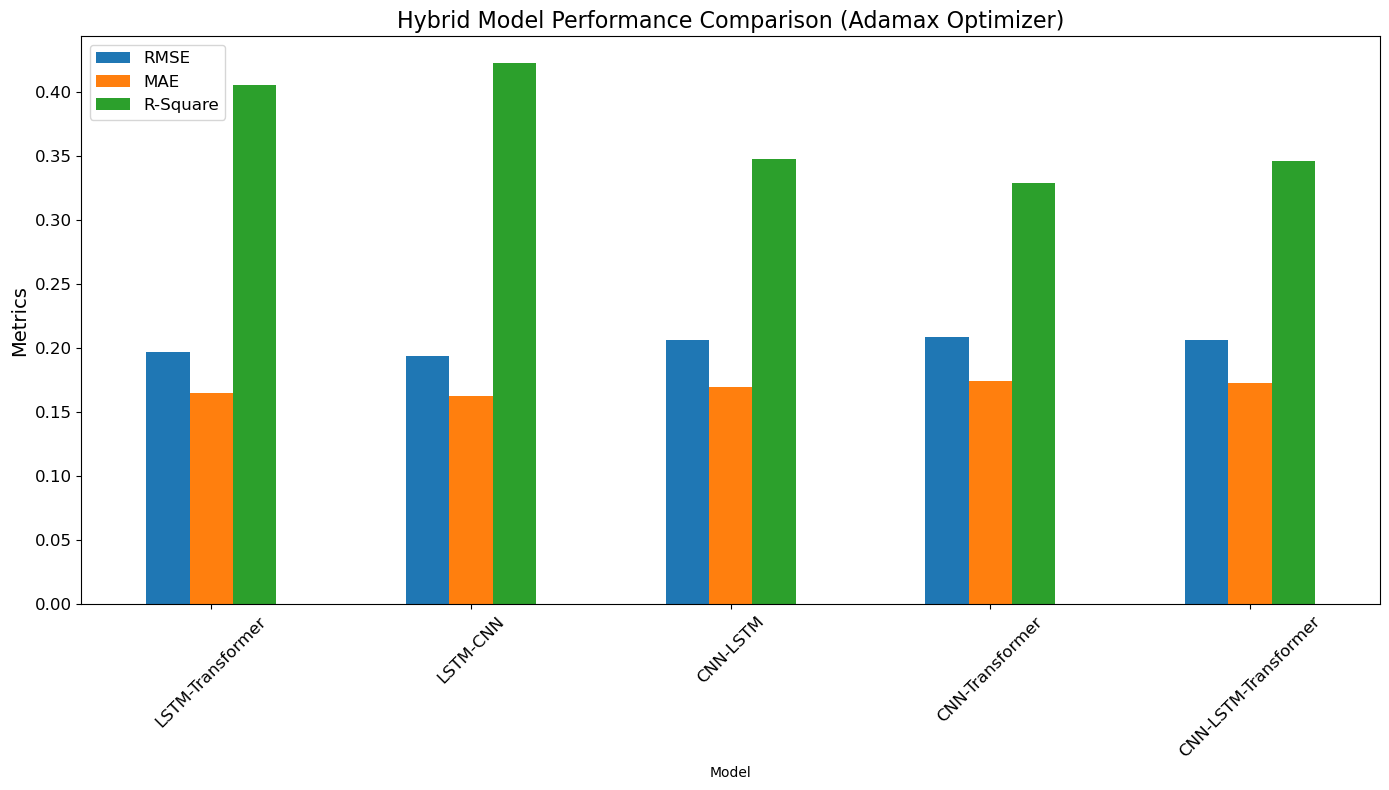

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, Flatten, MultiHeadAttention
from tensorflow.keras.optimizers import Adamax

# Define selected hybrid models with Adamax optimizer

def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model


def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model


def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model


def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model


def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model


# Define selected hybrid models in a list
hybrid_models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
]

hybrid_model_names = [
    "LSTM-Transformer",
    "LSTM-CNN",
    "CNN-LSTM",
    "CNN-Transformer",
    "CNN-LSTM-Transformer",
]

# Evaluate selected hybrid models
hybrid_results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

for name, model in zip(hybrid_model_names, hybrid_models):
    print(f"Training and evaluating hybrid model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    hybrid_results["Model"].append(name)
    hybrid_results["RMSE"].append(rmse)
    hybrid_results["MAE"].append(mae)
    hybrid_results["R-Square"].append(r2)

# Convert results to DataFrame
hybrid_results_df = pd.DataFrame(hybrid_results)
print(hybrid_results_df)

# Plot results
hybrid_results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Hybrid Model Performance Comparison (Adamax Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

## RMSPROP

C:\Users\Ayush\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\Ayush\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training and evaluating model: LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
Training and evaluating model: CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Training and evaluating model: Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
         Model      RMSE       MAE  R-Square
0         LSTM  0.190522  0.160345  0.443391
1          CNN  0.192349  0.161775  0.432662
2  Transformer  0.205202  0.171373  0.354309


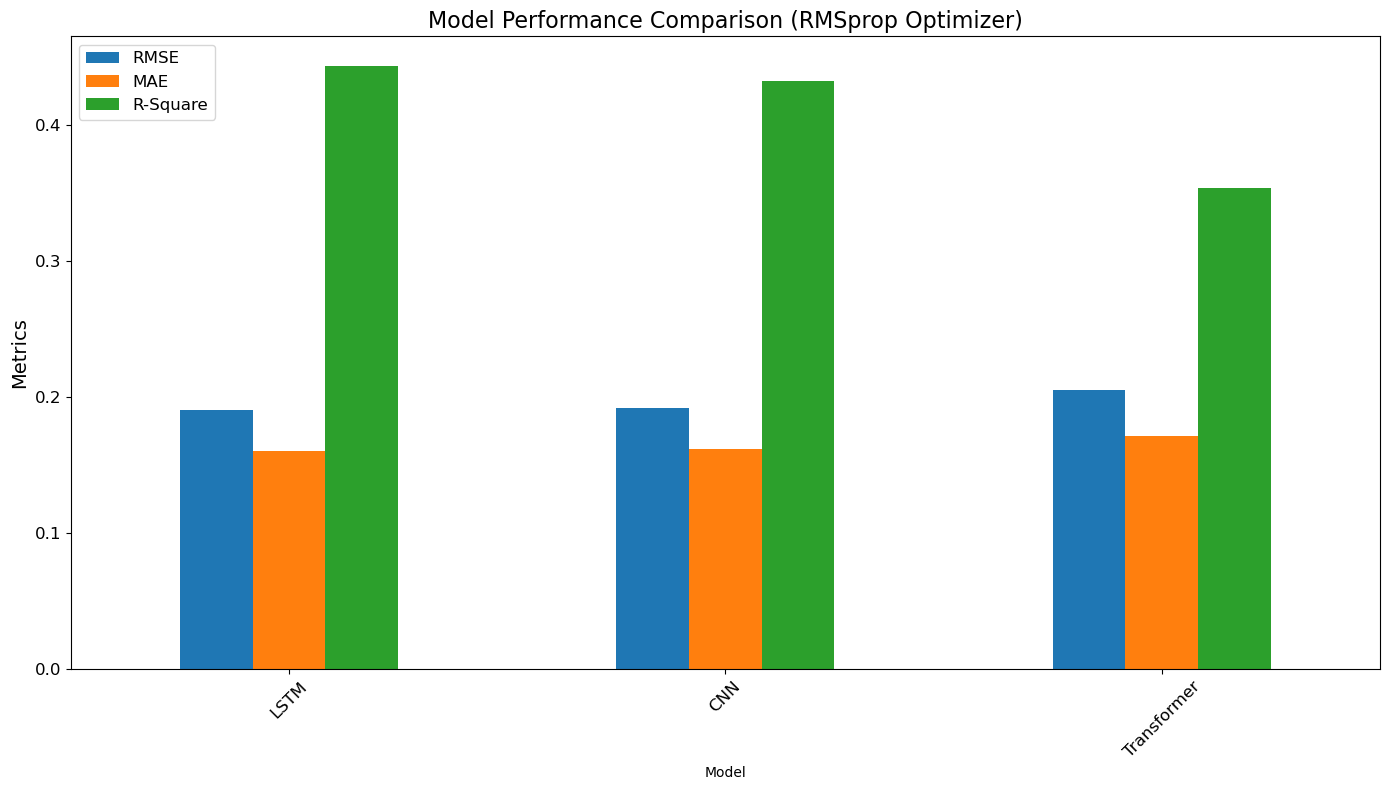

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten, Input, MultiHeadAttention, SimpleRNN
from tensorflow.keras.optimizers import RMSprop
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define individual models using RMSprop optimizer
def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn(input_shape):
    model = Sequential()
    model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(Flatten())
    model.add(Dense(1))
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

# Dataset preparation
# Assuming data is preprocessed into X_train_reshaped, y_train, X_test_reshaped, y_test

models = [
    build_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn((X_train_reshaped.shape[1], 1)),
    build_transformer((X_train_reshaped.shape[1], 1)),
]

model_names = [
    "LSTM",
    "CNN",
    "Transformer",
]

# Evaluate models
results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

for name, model in zip(model_names, models):
    print(f"Training and evaluating model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results["Model"].append(name)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    results["R-Square"].append(r2)

# Plotting results
results_df = pd.DataFrame(results)
print(results_df)

# Bar plot for comparison
results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Model Performance Comparison (RMSprop Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

### HYBRID

Training and evaluating hybrid model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
Training and evaluating hybrid model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
Training and evaluating hybrid model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step
Training and evaluating hybrid model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Training and evaluating hybrid model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.170591  0.152254  0.553756
1              LSTM-CNN  0.165463  0.143057  0.580179
2              CNN-LSTM  0.193213  0.161434  0.427553
3       CNN-Transformer  0.198160  0.170786  0.397866
4  CNN-LSTM-Transformer  0.201626  0.173201  0.376618


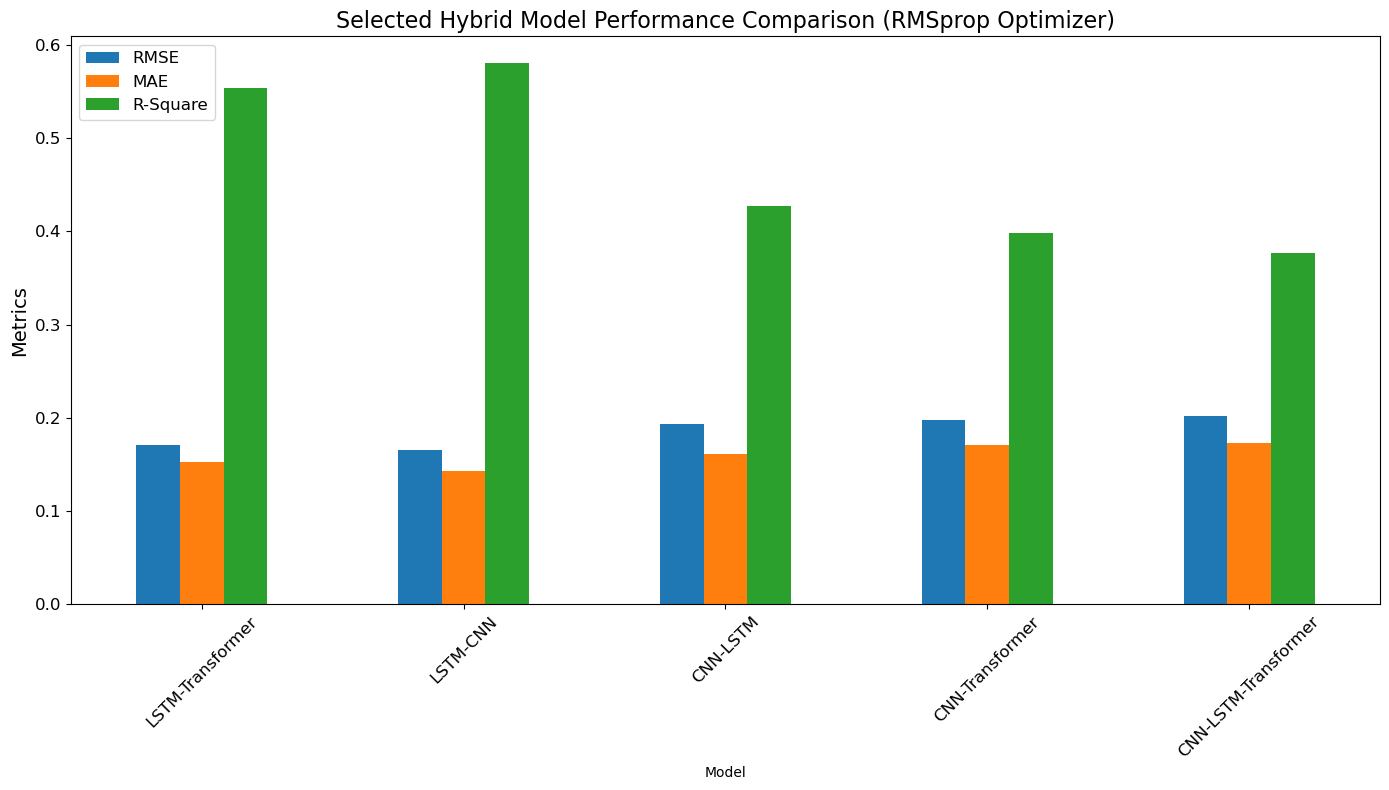

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, Flatten, MultiHeadAttention
from tensorflow.keras.optimizers import RMSprop

# Define selected hybrid models with RMSprop optimizer

def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

# Define only the selected hybrid models
selected_hybrid_models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
]

selected_hybrid_model_names = [
    "LSTM-Transformer",
    "LSTM-CNN",
    "CNN-LSTM",
    "CNN-Transformer",
    "CNN-LSTM-Transformer",
]

# Evaluate selected hybrid models
hybrid_results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

for name, model in zip(selected_hybrid_model_names, selected_hybrid_models):
    print(f"Training and evaluating hybrid model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    hybrid_results["Model"].append(name)
    hybrid_results["RMSE"].append(rmse)
    hybrid_results["MAE"].append(mae)
    hybrid_results["R-Square"].append(r2)

# Convert results to DataFrame
hybrid_results_df = pd.DataFrame(hybrid_results)
print(hybrid_results_df)

# Plot comparison
hybrid_results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Selected Hybrid Model Performance Comparison (RMSprop Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()


## ERROR TABLE

With adam

Training and evaluating: LSTM-Transformer with Adam optimizer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
Training and evaluating: LSTM-CNN with Adam optimizer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
Training and evaluating: CNN-LSTM with Adam optimizer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
Training and evaluating: CNN-Transformer with Adam optimizer
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step  
Training and evaluating: CNN-LSTM-Transformer with Adam optimizer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step

Hybrid Model Error Table (Adam Optimizer):
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.195807  0.163524  0.412081
1              LSTM-CNN  0.175219  0.151831  0.529217
2              CNN-LSTM  0.205302  0.168479  0.353682
3       CNN-Transformer  0.205041  0.173421  0.355320
4  CNN-LSTM-Transformer  0.224940  0.181978  0.224122


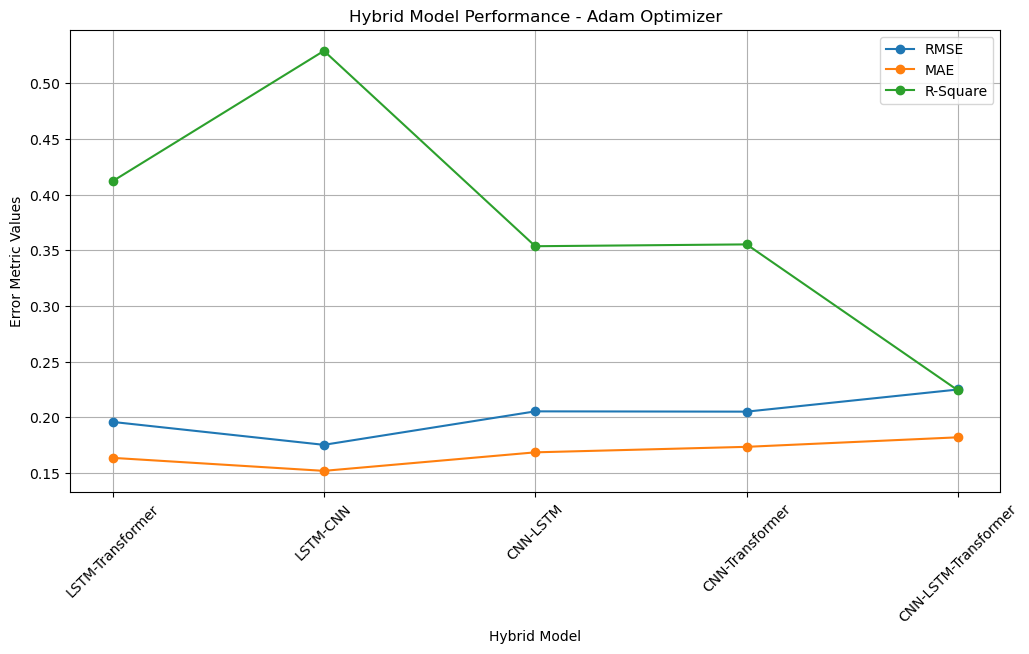

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, Flatten, MultiHeadAttention
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Function to evaluate model performance
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Define models with Adam optimizer
def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

# Train and evaluate models
hybrid_models = {
    "LSTM-Transformer": build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    "LSTM-CNN": build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    "CNN-LSTM": build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    "CNN-Transformer": build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    "CNN-LSTM-Transformer": build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
}

hybrid_results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

for name, model in hybrid_models.items():
    print(f"Training and evaluating: {name} with Adam optimizer")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped).squeeze()
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    
    hybrid_results["Model"].append(name)
    hybrid_results["RMSE"].append(rmse)
    hybrid_results["MAE"].append(mae)
    hybrid_results["R-Square"].append(r2)

# Convert results to DataFrame
error_table_adam = pd.DataFrame(hybrid_results)
print("\nHybrid Model Error Table (Adam Optimizer):")
print(error_table_adam)

# Save results (optional)
error_table_adam.to_csv("hybrid_model_error_table_adam.csv", index=False)

# Visualization
plt.figure(figsize=(12, 6))
for metric in ["RMSE", "MAE", "R-Square"]:
    plt.plot(error_table_adam["Model"], error_table_adam[metric], marker='o', label=metric)
    
plt.xlabel("Hybrid Model")
plt.ylabel("Error Metric Values")
plt.title("Hybrid Model Performance - Adam Optimizer")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
